# Notebook 01 — Exploratory Data Analysis & Data Preparation

**Module:** ITI113 Machine Learning & Operations Project  
**Project:** Explainable Diabetes Risk Screening Using Machine Learning and MLOps  
**Team:** Team 2
**Notebook Owner / Focus Area A (Data & EDA):** Fong Siang Yi (S202_8440104B)  
**Dataset:** `diabetes_012_health_indicators_BRFSS2015.csv` (CDC BRFSS 2015, via Kaggle — Diabetes Health Indicators Dataset)  
**Stage:** Progress Check — Assessment Component: Model Development Focus, Criterion "Data Understanding & Preprocessing"

---

## What this notebook does

This notebook implements the **Planned Data Quality and EDA Activities** committed to in Section 3.1 of the
Team 2 project proposal, and produces the model-ready artifacts consumed by Notebook 02 (baseline modelling)
and the MLOps data pipeline:

1. **Data ingestion & lineage** — load the raw BRFSS file, record a SHA-256 checksum, source and download metadata.
2. **Automated schema & data-quality validation** — verify types, ranges, class labels and the target-mapping decision against a documented codebook, and audit for missing values, invalid codes and duplicate profiles.
3. **Extensive Exploratory Data Analysis** — univariate, bivariate, statistical significance, correlation, multicollinearity, subgroup/fairness representation, and non-obvious interaction analysis, with every finding tied to a concrete impact on preprocessing, modelling or governance.
4. **Data cleaning, transformation and feature engineering** — type optimisation, seven engineered features with clinical/behavioural justification and quantitative validation against the target.
5. **Duplicate-safe, stratified 70/15/15 train/validation/test split** that keeps identical feature-target profiles together in a single partition (no leakage) — directly implements the proposal's data-governance commitment.
6. **Class-imbalance diagnostics** computed on the training partition only (no leakage into validation/test).
7. **Model-specific feature preparation** — a raw (tree-model-ready) feature set for XGBoost and a scaled (linear-model-ready) feature set for Logistic Regression, both fit on training data only.
8. **Persistence** of processed artifacts, a machine-readable data dictionary, an automated data-quality report and a lineage record — to local disk and, when running inside SageMaker Studio, to S3 for the shared MLOps pipeline.

## How to use this notebook

- **Kernel:** `Python 3 (Data Science 3.0)` (or later), instance `ml.t3.medium` is sufficient.
- **Before running:** place `diabetes_012_health_indicators_BRFSS2015.csv` (the file as downloaded from Kaggle,
  zipped or unzipped — the loader handles both) in a `data/` folder next to this notebook, **or** update
  `DATA_LOCAL_PATH` in the Configuration cell.
- **Team S3 bucket:** the notebook writes to the shared team prefix in `nyp-26s1-iti113`. If you are running
  outside SageMaker (e.g. locally, for review), set `S3_ENABLED = False` in the Configuration cell — all EDA,
  cleaning and feature-engineering steps still run and save locally.
- Run cells top to bottom. The notebook is self-contained and does not require internet access beyond the
  one-time package check.

## Target definition (from proposal Section 2.3)

`Diabetes_012` (0 = no diabetes, 1 = prediabetes, 2 = diabetes) is collapsed into the binary screening target
`Diabetes_binary`: **0 = no diabetes**, **1 = prediabetes or diabetes**. All 253,680 records are retained (the
project deliberately does not use the artificially class-balanced Kaggle variant — see proposal Section 2.3).


## 1. Environment Setup

Installs/validates the libraries used in this notebook and detects whether we are running inside a SageMaker
kernel (in which case raw/processed artifacts are also pushed to S3 for the shared MLOps pipeline).


In [ ]:
# If a required package is missing in the kernel, uncomment the line below and rerun,
# then restart the kernel before continuing. All packages below ship with the
# SageMaker Studio "Data Science 3.0" image, so this is normally a no-op.
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn boto3 sagemaker


In [ ]:
import os
import io
import json
import hashlib
import zipfile
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

# Detect whether we are running inside a SageMaker-managed kernel.
try:
    import boto3
    import sagemaker
    sm_session = sagemaker.Session()
    sm_role = sagemaker.get_execution_role()
    sm_region = boto3.Session().region_name
    RUNNING_IN_SAGEMAKER = True
    print("SageMaker session detected.")
    print(f"  Region : {sm_region}")
    print(f"  Role   : {sm_role.split('/')[-1]}")
except Exception as exc:
    RUNNING_IN_SAGEMAKER = False
    sm_session, sm_role, sm_region = None, None, None
    print("Not running inside a SageMaker execution role (this is fine outside Studio).")
    print(f"  Reason: {exc}")


Not running inside a SageMaker execution role (this is fine outside Studio).
  Reason: module 'sagemaker' has no attribute 'Session'


## 2. Project Configuration

Single source of truth for paths, S3 locations and reproducibility settings. Edit `TEAM_ID` and the S3 bucket
name if your cohort uses a different convention; everything downstream references these variables only.


In [ ]:
# --- Team / governance identifiers -------------------------------------------------
TEAM_ID       = "team02"                 # Team 2
NOTEBOOK_OWNER = "Fong Siang Yi (8440104B) — Focus Area A: Data & EDA / Model B: XGBoost"
SUBMISSION_STAGE = "Progress Check"

# --- Storage ------------------------------------------------------------------------
S3_ENABLED   = RUNNING_IN_SAGEMAKER      # set False to force local-only execution (e.g. local review)
S3_BUCKET    = "nyp-26s1-iti113"
S3_PREFIX    = f"iti113/{TEAM_ID}/data/diabetes-brfss2015"

LOCAL_DATA_DIR      = "./data"
LOCAL_PROCESSED_DIR = "./data/processed"
LOCAL_REPORTS_DIR    = "./reports"
for _dir in (LOCAL_DATA_DIR, LOCAL_PROCESSED_DIR, LOCAL_REPORTS_DIR):
    os.makedirs(_dir, exist_ok=True)

RAW_FILENAME    = "diabetes_012_health_indicators_BRFSS2015.csv"
DATA_LOCAL_PATH = os.path.join(LOCAL_DATA_DIR, RAW_FILENAME)

# --- Reproducibility -----------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Split ratios (proposal Section 3: "stratified 70/15/15 split or equivalent") ----
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15
assert abs(TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0) < 1e-9

# --- Columns --------------------------------------------------------------------------
TARGET_012 = "Diabetes_012"     # source 3-class label (0/1/2)
TARGET_BIN = "Diabetes_binary"  # derived binary screening target (0/1)

BINARY_FEATURES = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex",
]
ORDINAL_FEATURES    = ["GenHlth", "Age", "Education", "Income"]
COUNT_FEATURES      = ["MentHlth", "PhysHlth"]
CONTINUOUS_FEATURES = ["BMI"]
RAW_FEATURES = BINARY_FEATURES + ORDINAL_FEATURES + COUNT_FEATURES + CONTINUOUS_FEATURES

print(f"S3 persistence enabled : {S3_ENABLED}")
print(f"Raw feature count      : {len(RAW_FEATURES)}")
print(f"Expected S3 prefix     : s3://{S3_BUCKET}/{S3_PREFIX}")


S3 persistence enabled : False
Raw feature count      : 21
Expected S3 prefix     : s3://nyp-26s1-iti113/iti113/team02/data/diabetes-brfss2015


## 3. Data Dictionary (Codebook)

Documenting variable definitions, encodings and expected ranges **before** touching the data is a governance
requirement in the proposal (Section 3: "Data dictionary and feature catalogue"). This codebook drives the
automated schema validation in Section 6 and is exported as a reusable artifact in Section 27.


In [ ]:
DATA_DICTIONARY = pd.DataFrame([
    # column, description, dtype, valid_min, valid_max, feature_group, notes
    ("Diabetes_012", "0=no diabetes, 1=prediabetes, 2=diabetes (self-reported, source label)", "ordinal", 0, 2, "target", "Source of the derived binary target."),
    ("HighBP", "Ever told has high blood pressure", "binary", 0, 1, "clinical", ""),
    ("HighChol", "Ever told has high cholesterol", "binary", 0, 1, "clinical", ""),
    ("CholCheck", "Cholesterol check within past 5 years", "binary", 0, 1, "healthcare_access", ""),
    ("BMI", "Body Mass Index, computed from self-reported height/weight", "continuous", 12, 98, "clinical", "Self-report measurement error possible."),
    ("Smoker", "Smoked >= 100 cigarettes in lifetime", "binary", 0, 1, "lifestyle", ""),
    ("Stroke", "Ever told had a stroke", "binary", 0, 1, "clinical", ""),
    ("HeartDiseaseorAttack", "Coronary heart disease or myocardial infarction", "binary", 0, 1, "clinical", ""),
    ("PhysActivity", "Physical activity in past 30 days (excl. job)", "binary", 0, 1, "lifestyle", ""),
    ("Fruits", "Consumes fruit >= 1 time/day", "binary", 0, 1, "lifestyle", ""),
    ("Veggies", "Consumes vegetables >= 1 time/day", "binary", 0, 1, "lifestyle", ""),
    ("HvyAlcoholConsump", "Heavy alcohol consumption (>14/wk men, >7/wk women)", "binary", 0, 1, "lifestyle", ""),
    ("AnyHealthcare", "Has any kind of healthcare coverage", "binary", 0, 1, "healthcare_access", ""),
    ("NoDocbcCost", "Needed to see a doctor but could not, due to cost, in past 12 months", "binary", 0, 1, "healthcare_access", ""),
    ("GenHlth", "Self-rated general health, 1=Excellent ... 5=Poor", "ordinal", 1, 5, "self_reported", "Subjective; strongest single correlate of the target."),
    ("MentHlth", "Days of poor mental health in past 30 days", "count", 0, 30, "self_reported", "Top-coded at 30 — see Section 11."),
    ("PhysHlth", "Days of poor physical health in past 30 days", "count", 0, 30, "self_reported", "Top-coded at 30 — see Section 11."),
    ("DiffWalk", "Serious difficulty walking or climbing stairs", "binary", 0, 1, "self_reported", ""),
    ("Sex", "0=female, 1=male", "binary", 0, 1, "demographic", "Protected attribute — governance/fairness lens."),
    ("Age", "13-level age category (1=18-24 ... 13=80+)", "ordinal", 1, 13, "demographic", "Protected attribute — governance/fairness lens."),
    ("Education", "Education level, 1=None/Elementary ... 6=College graduate", "ordinal", 1, 6, "demographic", "Socioeconomic — fairness lens."),
    ("Income", "Income category, 1=<$10k ... 8=>=$75k", "ordinal", 1, 8, "demographic", "Socioeconomic — fairness lens."),
], columns=["column", "description", "dtype", "valid_min", "valid_max", "feature_group", "notes"])

DATA_DICTIONARY


,column,description,dtype,valid_min,valid_max,feature_group,notes
0,Diabetes_012,"0=no diabetes, 1=prediabetes, 2=diabetes (self...",ordinal,0,2,target,Source of the derived binary target.
1,HighBP,Ever told has high blood pressure,binary,0,1,clinical,
2,HighChol,Ever told has high cholesterol,binary,0,1,clinical,
3,CholCheck,Cholesterol check within past 5 years,binary,0,1,healthcare_access,
4,BMI,"Body Mass Index, computed from self-reported h...",continuous,12,98,clinical,Self-report measurement error possible.
5,Smoker,Smoked >= 100 cigarettes in lifetime,binary,0,1,lifestyle,
6,Stroke,Ever told had a stroke,binary,0,1,clinical,
7,HeartDiseaseorAttack,Coronary heart disease or myocardial infarction,binary,0,1,clinical,
8,PhysActivity,Physical activity in past 30 days (excl. job),binary,0,1,lifestyle,
9,Fruits,Consumes fruit >= 1 time/day,binary,0,1,lifestyle,


## 4. Data Ingestion & Lineage

Per proposal Section 3 ("Data lineage: record source URLs, original file names, download date, SHA-256
checksum..."), we compute a checksum of the raw file as loaded and record the full lineage record before any
transformation. The loader is defensive: Kaggle downloads are frequently zip-compressed, so `load_dataset`
transparently extracts a CSV if the source file is a zip archive.


In [ ]:
# Update the path to look in the current directory instead of the 'data/' subfolder
DATA_LOCAL_PATH = 'diabetes_012_health_indicators_BRFSS2015.csv'

df_raw = load_dataset(DATA_LOCAL_PATH)

Source was zip-compressed — extracted CSV to: ./data/_extracted/diabetes_012_health_indicators_BRFSS2015.csv


In [ ]:
#import pandas as pd

# Read directly from your team's S3 raw data bucket
#s3_uri = 's3://nyp-26s1-iti113/iti113/team02/data/diabetes/raw/diabetes_012_health_indicators_BRFSS2015.csv'
#df_raw = pd.read_csv(s3_uri)

#print(f"Dataset successfully loaded. Shape: {df_raw.shape}")

/opt/conda/lib/python3.12/site-packages/fsspec/registry.py:305: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


FileNotFoundError: nyp-26s1-iti113/iti113/team02/data/diabetes/raw/diabetes_012_health_indicators_BRFSS2015.csv

In [ ]:
def sha256_of_file(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 16), b""):
            h.update(chunk)
    return h.hexdigest()


def load_dataset(path: str, extract_dir: str = "./data/_extracted") -> pd.DataFrame:
    # Load the BRFSS CSV. Transparently handles the common case where the
    # downloaded Kaggle file is a zip archive rather than a raw CSV.
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find '{path}'. Upload diabetes_012_health_indicators_BRFSS2015.csv "
            f"(zipped or unzipped) into '{LOCAL_DATA_DIR}/' and rerun this cell."
        )
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as zf:
            csv_names = [n for n in zf.namelist() if n.lower().endswith(".csv")]
            if not csv_names:
                raise FileNotFoundError(f"No CSV found inside zip archive: {path}")
            os.makedirs(extract_dir, exist_ok=True)
            zf.extract(csv_names[0], extract_dir)
            path = os.path.join(extract_dir, csv_names[0])
            print(f"Source was zip-compressed — extracted CSV to: {path}")
    return pd.read_csv(path)


df_raw = load_dataset(DATA_LOCAL_PATH)

LINEAGE = {
    "source_name": "Diabetes Health Indicators Dataset (Kaggle, contributor: alexteboul)",
    "source_url": "https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data",
    "underlying_survey": "CDC BRFSS 2015 (Behavioral Risk Factor Surveillance System)",
    "primary_file": RAW_FILENAME,
    "sha256_checksum": sha256_of_file(DATA_LOCAL_PATH),
    "loaded_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "n_rows": int(df_raw.shape[0]),
    "n_columns": int(df_raw.shape[1]),
    "notebook_owner": NOTEBOOK_OWNER,
    "team_id": TEAM_ID,
}
print(json.dumps(LINEAGE, indent=2))


Source was zip-compressed — extracted CSV to: ./data/_extracted/diabetes_012_health_indicators_BRFSS2015.csv


{
  "source_name": "Diabetes Health Indicators Dataset (Kaggle, contributor: alexteboul)",
  "source_url": "https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data",
  "underlying_survey": "CDC BRFSS 2015 (Behavioral Risk Factor Surveillance System)",
  "primary_file": "diabetes_012_health_indicators_BRFSS2015.csv",
  "sha256_checksum": "463b5430e1cea3c518227f3179317f2e3c9ccd4f76fb7e7ea125bf87305aee98",
  "loaded_at_utc": "2026-08-12T05:01:33+00:00",
  "n_rows": 253680,
  "n_columns": 22,
  "notebook_owner": "Fong Siang Yi (8440104B) \u2014 Focus Area A: Data & EDA / Model B: XGBoost",
  "team_id": "team02"
}


In [ ]:
# Upload the raw file to S3 for version control (governance: retain original alongside checksum)
if S3_ENABLED:
    s3 = boto3.client("s3")
    raw_key = f"{S3_PREFIX}/raw/{RAW_FILENAME}"
    s3.upload_file(DATA_LOCAL_PATH, S3_BUCKET, raw_key)
    RAW_S3_URI = f"s3://{S3_BUCKET}/{raw_key}"
    print(f"Raw dataset uploaded to: {RAW_S3_URI}")
else:
    s3 = None
    RAW_S3_URI = None
    print("S3 disabled — skipping raw upload (local lineage record still captured above).")


S3 disabled — skipping raw upload (local lineage record still captured above).


## 5. Structural Overview

A first look at shape, types and summary statistics, before any validation or cleaning.


In [ ]:
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head())


Shape: 253,680 rows x 22 columns


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [ ]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## 6. Automated Schema & Range Validation

Governance requires "automated checks for schema, ranges, class ratio, duplicate profiles and target mapping
before training and inference" (proposal Section 3). This is implemented here as a reusable function so the
MLOps team can call the same check on any future data refresh — it does not just print a one-off summary.


In [ ]:
def validate_schema(data: pd.DataFrame, codebook: pd.DataFrame) -> pd.DataFrame:
    # Validate that every column in `codebook` exists in `data`, with no nulls and
    # values within the documented [valid_min, valid_max] range. Returns a per-column report.
    rows = []
    for _, spec in codebook.iterrows():
        col = spec["column"]
        present = col in data.columns
        n_null = int(data[col].isnull().sum()) if present else None
        actual_min = float(data[col].min()) if present else None
        actual_max = float(data[col].max()) if present else None
        in_range = (
            present
            and n_null == 0
            and actual_min >= spec["valid_min"]
            and actual_max <= spec["valid_max"]
        )
        rows.append({
            "column": col, "present": present, "n_null": n_null,
            "expected_range": f'[{spec["valid_min"]}, {spec["valid_max"]}]',
            "actual_min": actual_min, "actual_max": actual_max, "pass": in_range,
        })
    return pd.DataFrame(rows)


schema_report = validate_schema(df_raw, DATA_DICTIONARY)
display(schema_report)

n_failed = (~schema_report["pass"]).sum()
if n_failed == 0:
    print("SCHEMA VALIDATION: PASS — all columns present, no nulls, all values within documented range.")
else:
    failed_cols = schema_report.loc[~schema_report["pass"], "column"].tolist()
    raise ValueError(f"Schema validation FAILED for columns: {failed_cols}. Investigate before proceeding.")


,column,present,n_null,expected_range,actual_min,actual_max,pass
0,Diabetes_012,True,0,"[0, 2]",0.0,2.0,True
1,HighBP,True,0,"[0, 1]",0.0,1.0,True
2,HighChol,True,0,"[0, 1]",0.0,1.0,True
3,CholCheck,True,0,"[0, 1]",0.0,1.0,True
4,BMI,True,0,"[12, 98]",12.0,98.0,True
5,Smoker,True,0,"[0, 1]",0.0,1.0,True
6,Stroke,True,0,"[0, 1]",0.0,1.0,True
7,HeartDiseaseorAttack,True,0,"[0, 1]",0.0,1.0,True
8,PhysActivity,True,0,"[0, 1]",0.0,1.0,True
9,Fruits,True,0,"[0, 1]",0.0,1.0,True


SCHEMA VALIDATION: PASS — all columns present, no nulls, all values within documented range.


## 7. Missing Value & Special-Code Audit

**Finding:** the Kaggle-cleaned file has zero conventional (`NaN`) missing values, confirmed above. However,
the *original* BRFSS survey instrument uses special codes such as `7`/`77` ("Don't know") and `9`/`99`
("Refused") for several items. The schema check above confirms none of those out-of-range codes remain in this
cleaned extract — the contributor's cleaning step already removed or excluded such responses.

**Why this matters / governance impact:** the absence of a "don't know / refused" category means the dataset
silently drops non-response, which is itself a form of survey/response bias (proposal risk register:
*Self-report and measurement bias*). We do not have visibility into how many original respondents were
excluded this way, so it is documented here as a **known limitation to disclose in the model card**, not a
data-quality defect. No imputation is required for this dataset.


In [ ]:
missing_summary = df_raw.isnull().sum()
print("Missing values per column:")
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "  None — 0 missing values across all 22 columns.")


Missing values per column:
  None — 0 missing values across all 22 columns.


## 8. Duplicate Profile Analysis

The proposal commits to analysing exact duplicate feature-target profiles **before** splitting (Section 3.1)
because BRFSS responses were reduced to only 21 low-cardinality (mostly binary/ordinal) indicators, so two
genuinely different respondents can easily share an identical profile by chance — these are not necessarily
data-entry duplicates.


In [ ]:
n_dup_default = int(df_raw.duplicated().sum())                 # rows that are repeats of an earlier row
dup_group_mask = df_raw.duplicated(keep=False)                 # every row that belongs to a duplicate group
n_dup_group = int(dup_group_mask.sum())

print(f"Exact duplicate rows (pandas default, keep='first') : {n_dup_default:,} ({n_dup_default/len(df_raw):.2%} of rows)")
print(f"Rows that belong to ANY duplicate-profile group      : {n_dup_group:,} ({n_dup_group/len(df_raw):.2%} of rows)")


Exact duplicate rows (pandas default, keep='first') : 23,899 (9.42% of rows)
Rows that belong to ANY duplicate-profile group      : 35,086 (13.83% of rows)


In [ ]:
# Non-obvious finding: are duplicate profiles concentrated in one class?
tmp = df_raw.copy()
tmp[TARGET_BIN] = (tmp[TARGET_012] > 0).astype(int)

dup_class_share = tmp.loc[dup_group_mask, TARGET_BIN].value_counts(normalize=True).sort_index()
overall_class_share = tmp[TARGET_BIN].value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    "share_in_duplicate_groups": dup_class_share,
    "share_in_full_dataset": overall_class_share,
})
comparison.index = ["No diabetes (0)", "Prediabetes/diabetes (1)"]
display(comparison.style.format("{:.2%}"))

print(
    "\nFinding: duplicate profiles are heavily concentrated in the NEGATIVE class "
    f"({dup_class_share.get(0, 0):.1%} of duplicate rows vs {overall_class_share.get(0, 0):.1%} overall)."
    " This is expected: with only 21 largely binary/ordinal indicators, low-risk 'all-clear' respondent"
    " profiles are far more likely to coincide exactly than higher-risk profiles, which vary across more"
    " comorbidities and severities."
)
print(
    "\nImpact on preprocessing/modelling: naive row-level deduplication would disproportionately remove"
    " common healthy profiles, artificially inflating the positive-class rate and biasing the training"
    " distribution. We therefore RETAIN all rows (matching the proposal's decision to use the full,"
    " naturally-imbalanced dataset), but ensure identical feature-target profiles are never split across"
    " train/validation/test partitions (Section 23) to prevent evaluation leakage, and we persist a"
    " deduplicated sensitivity dataset (Section 29) for the modelling team's leakage/inflation check called"
    " for in the proposal."
)


,share_in_duplicate_groups,share_in_full_dataset
No diabetes (0),98.62%,84.24%
Prediabetes/diabetes (1),1.38%,15.76%



Finding: duplicate profiles are heavily concentrated in the NEGATIVE class (98.6% of duplicate rows vs 84.2% overall). This is expected: with only 21 largely binary/ordinal indicators, low-risk 'all-clear' respondent profiles are far more likely to coincide exactly than higher-risk profiles, which vary across more comorbidities and severities.

Impact on preprocessing/modelling: naive row-level deduplication would disproportionately remove common healthy profiles, artificially inflating the positive-class rate and biasing the training distribution. We therefore RETAIN all rows (matching the proposal's decision to use the full, naturally-imbalanced dataset), but ensure identical feature-target profiles are never split across train/validation/test partitions (Section 23) to prevent evaluation leakage, and we persist a deduplicated sensitivity dataset (Section 29) for the modelling team's leakage/inflation check called for in the proposal.


## 9. Target Definition & Derivation

Derive the binary screening target per proposal Section 2.3, and verify the resulting distribution against
the percentages already reported in the proposal (84.24% / 15.76%) as an independent check that the mapping
was implemented correctly.


In [ ]:
df = df_raw.copy()
df[TARGET_BIN] = (df[TARGET_012] > 0).astype(int)

three_class_counts = df[TARGET_012].value_counts().sort_index()
binary_counts = df[TARGET_BIN].value_counts().sort_index()
binary_pct = df[TARGET_BIN].value_counts(normalize=True).sort_index() * 100

print("Three-class source label (Diabetes_012):")
print(three_class_counts.rename({0.0: "No diabetes", 1.0: "Prediabetes", 2.0: "Diabetes"}))
print("\nDerived binary target (Diabetes_binary):")
for cls, cnt in binary_counts.items():
    label = "No diabetes" if cls == 0 else "Prediabetes or diabetes"
    print(f"  {cls} ({label}): {cnt:,} ({binary_pct[cls]:.2f}%)")

expected = {0: 84.24, 1: 15.76}
for cls, exp_pct in expected.items():
    assert abs(binary_pct[cls] - exp_pct) < 0.01, f"Class {cls} pct {binary_pct[cls]:.2f} != expected {exp_pct}"
print("\nCross-check against proposal Section 2.3 figures (84.24% / 15.76%): PASS")


Three-class source label (Diabetes_012):
Diabetes_012
No diabetes    213703
Prediabetes      4631
Diabetes        35346
Name: count, dtype: int64

Derived binary target (Diabetes_binary):
  0 (No diabetes): 213,703 (84.24%)
  1 (Prediabetes or diabetes): 39,977 (15.76%)

Cross-check against proposal Section 2.3 figures (84.24% / 15.76%): PASS


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors_3 = ["#5B9BD5", "#F4B183", "#ED7D31"]
axes[0].bar(["No diabetes\n(0)", "Prediabetes\n(1)", "Diabetes\n(2)"], three_class_counts.values, color=colors_3)
axes[0].set_title("Source label — three classes", fontweight="bold")
axes[0].set_ylabel("Respondents")
for i, v in enumerate(three_class_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}", ha="center", fontweight="bold", fontsize=9)

colors_2 = ["#5B9BD5", "#ED7D31"]
axes[1].bar(["No diabetes (0)", "Prediabetes or\ndiabetes (1)"], binary_counts.values, color=colors_2)
axes[1].set_title("Derived screening target — binary", fontweight="bold")
for i, v in enumerate(binary_counts.values):
    pct = binary_pct.values[i]
    axes[1].text(i, v + 2000, f"{v:,}\n({pct:.1f}%)", ha="center", fontweight="bold", fontsize=9)

plt.suptitle("Target Distribution: Source Label vs. Derived Screening Target", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(
    "Class imbalance is substantial (~5.3:1). Per the proposal's Success Metrics (Section 1.6), accuracy will"
    " NOT be used as the primary metric — recall, F1/F2, and Average Precision are prioritised, and class"
    " weighting is computed on the training split only (Section 24)."
)


## 10. EDA Part 1 — Univariate Distributions

### 10.1 Binary lifestyle / clinical / access indicators


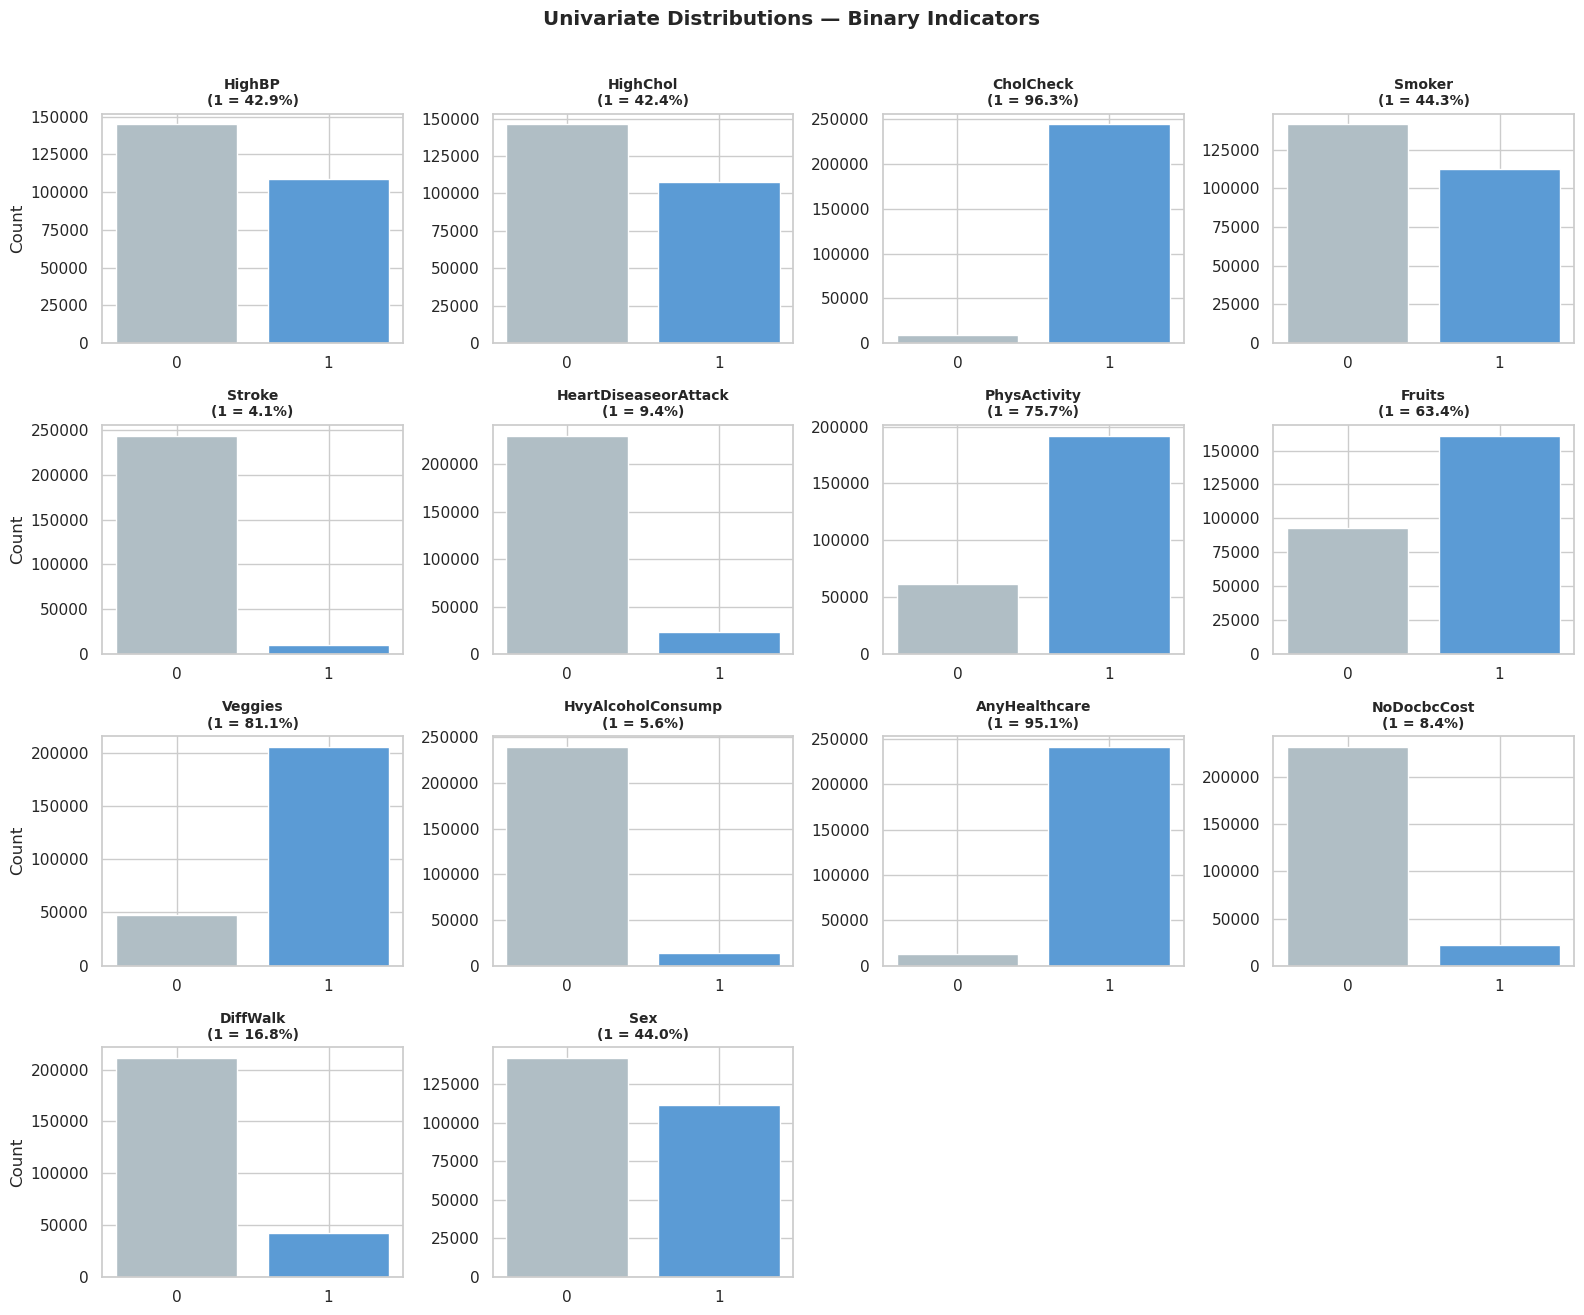

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.flatten()
for i, col in enumerate(BINARY_FEATURES):
    rate = df[col].mean() * 100
    axes[i].bar(["0", "1"], df[col].value_counts().sort_index().values, color=["#B0BEC5", "#5B9BD5"])
    axes[i].set_title(f"{col}\n(1 = {rate:.1f}%)", fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Count" if i % 4 == 0 else "")
for j in range(len(BINARY_FEATURES), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Univariate Distributions — Binary Indicators", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 10.2 Ordinal, count and continuous indicators


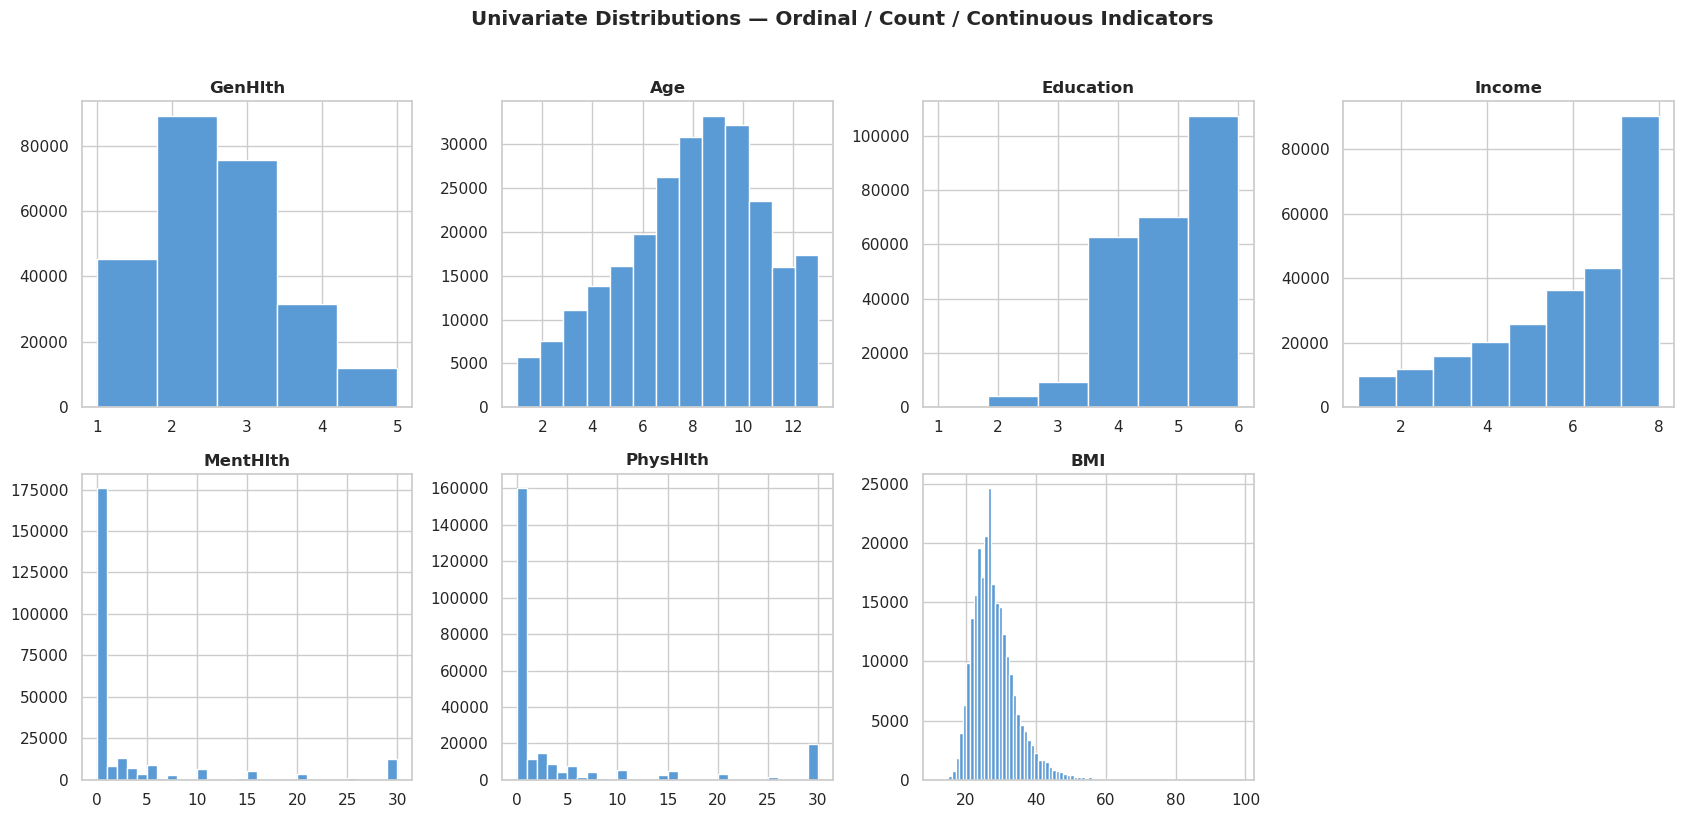

                mean       std   min   25%   50%   75%   max
GenHlth     2.511392  1.068477   1.0   2.0   2.0   3.0   5.0
Age         8.032119  3.054220   1.0   6.0   8.0  10.0  13.0
Education   5.050434  0.985774   1.0   4.0   5.0   6.0   6.0
Income      6.053875  2.071148   1.0   5.0   7.0   8.0   8.0
MentHlth    3.184772  7.412847   0.0   0.0   0.0   2.0  30.0
PhysHlth    4.242081  8.717951   0.0   0.0   0.0   3.0  30.0
BMI        28.382364  6.608694  12.0  24.0  27.0  31.0  98.0


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.flatten()
plot_cols = ORDINAL_FEATURES + COUNT_FEATURES + CONTINUOUS_FEATURES
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=30 if col in COUNT_FEATURES else df[col].nunique(), color="#5B9BD5", edgecolor="white")
    axes[i].set_title(col, fontweight="bold")
axes[-1].set_visible(False)
plt.suptitle("Univariate Distributions — Ordinal / Count / Continuous Indicators", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(df[plot_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]])


## 11. EDA Part 2 — Outlier & Data-Integrity Review

Two non-obvious integrity patterns worth flagging before modelling:

1. **BMI has a long right tail up to 98** — physiologically extreme but not impossible (self-reported
   height/weight in a population survey), so we treat these as legitimate high-leverage points rather than
   errors, and rely on tree-based models (robust to outliers) plus a `BMI_Category` clinical banding
   (Section 21) that caps their leverage for the linear baseline.
2. **`MentHlth` and `PhysHlth` show a spike at exactly 30 days** — a classic **top-coding / ceiling effect**
   in survey instruments that cap "number of days" questions at the recall period. Respondents whose true
   burden exceeds 30 days are indistinguishable from those at exactly 30, which compresses the top of the
   distribution and should be kept in mind when interpreting these features' contribution.


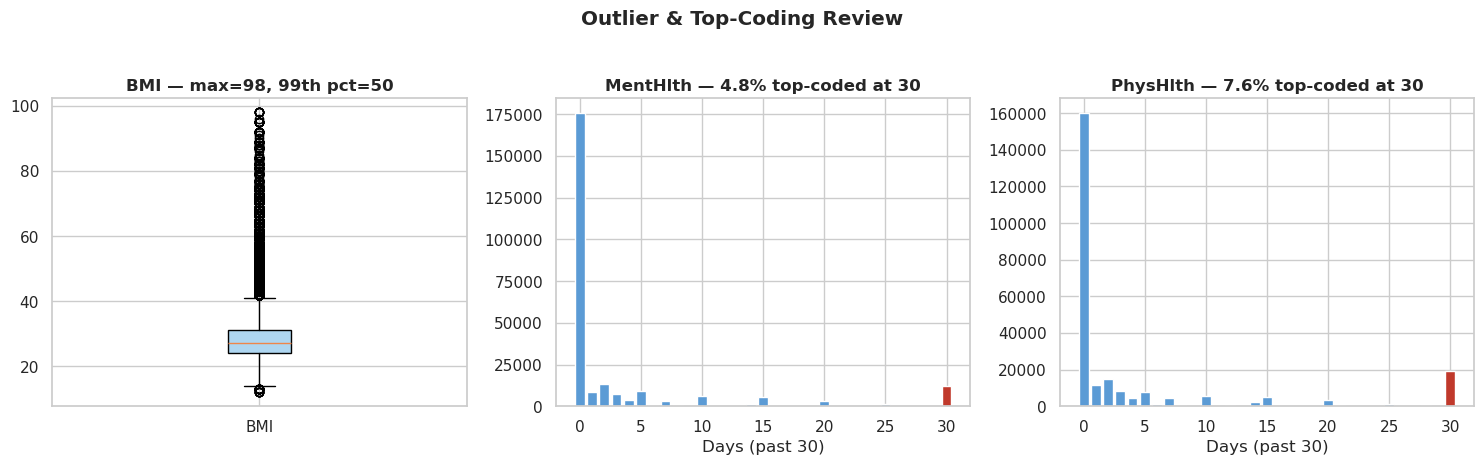

Respondents with BMI >= 50 (severe/extreme obesity range): 2,547 (1.00%)
MentHlth == 30 (ceiling): 12,088 (4.77%)
PhysHlth == 30 (ceiling): 19,400 (7.65%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].boxplot(df["BMI"], vert=True, patch_artist=True, boxprops=dict(facecolor="#AED6F1"))
axes[0].set_title(f"BMI — max={df['BMI'].max():.0f}, 99th pct={df['BMI'].quantile(0.99):.0f}", fontweight="bold")
axes[0].set_xticklabels(["BMI"])

for ax, col in zip(axes[1:], ["MentHlth", "PhysHlth"]):
    counts = df[col].value_counts().sort_index()
    colors = ["#5B9BD5"] * 31
    colors[30] = "#C0392B"
    ax.bar(counts.index, counts.values, color=colors)
    ceiling_pct = (df[col] == 30).mean() * 100
    ax.set_title(f"{col} — {ceiling_pct:.1f}% top-coded at 30", fontweight="bold")
    ax.set_xlabel("Days (past 30)")

plt.suptitle("Outlier & Top-Coding Review", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(f"Respondents with BMI >= 50 (severe/extreme obesity range): {(df['BMI'] >= 50).sum():,} ({(df['BMI']>=50).mean():.2%})")
print(f"MentHlth == 30 (ceiling): {(df['MentHlth']==30).sum():,} ({(df['MentHlth']==30).mean():.2%})")
print(f"PhysHlth == 30 (ceiling): {(df['PhysHlth']==30).sum():,} ({(df['PhysHlth']==30).mean():.2%})")


## 12. EDA Part 3 — Bivariate Analysis: Prevalence Lift by Binary Indicator

For each binary indicator, we compare the diabetes/prediabetes prevalence when the indicator is present (1)
vs. absent (0). This ranks indicators by practical (not just statistical) importance and previews which raw
features are likely to dominate feature-importance rankings in Notebook 02's XGBoost model.


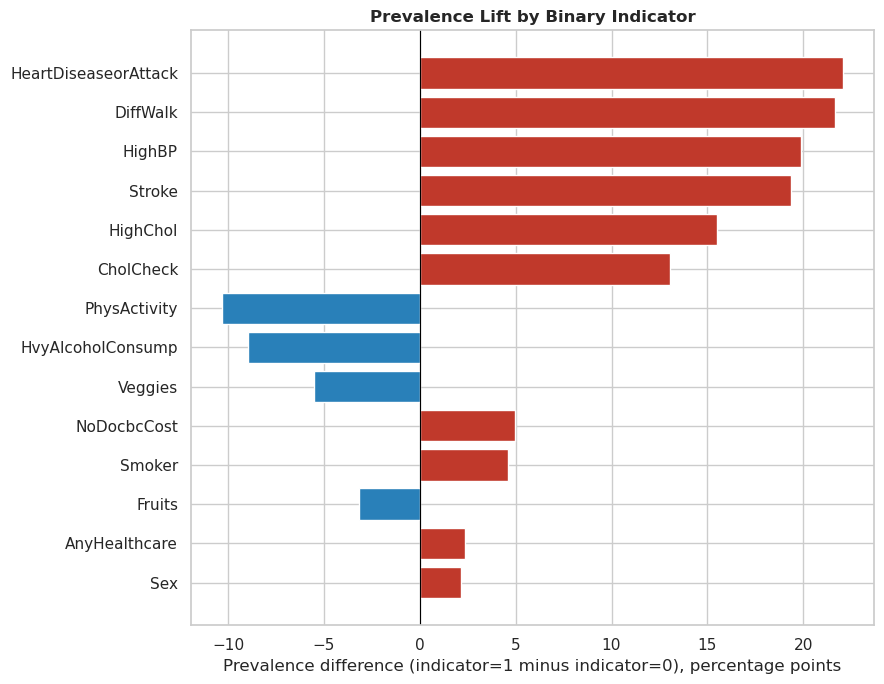

,feature,prevalence_if_0,prevalence_if_1,lift
0,HeartDiseaseorAttack,13.68%,35.75%,+22.07%
1,DiffWalk,12.12%,33.76%,+21.64%
2,HighBP,7.22%,27.12%,+19.90%
3,Stroke,14.97%,34.33%,+19.35%
4,HighChol,9.18%,24.69%,+15.50%
5,CholCheck,3.20%,16.25%,+13.05%
6,PhysActivity,23.56%,13.25%,-10.31%
7,HvyAlcoholConsump,16.26%,7.30%,-8.97%
8,Veggies,20.23%,14.72%,-5.52%
9,NoDocbcCost,15.34%,20.33%,+4.99%


In [ ]:
prevalence_lift = []
for col in BINARY_FEATURES:
    rate_0 = df.loc[df[col] == 0, TARGET_BIN].mean()
    rate_1 = df.loc[df[col] == 1, TARGET_BIN].mean()
    prevalence_lift.append({"feature": col, "prevalence_if_0": rate_0, "prevalence_if_1": rate_1, "lift": rate_1 - rate_0})
lift_df = pd.DataFrame(prevalence_lift).sort_values("lift", key=abs, ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
y_pos = np.arange(len(lift_df))
colors = ["#C0392B" if v > 0 else "#2980B9" for v in lift_df["lift"]]
ax.barh(y_pos, lift_df["lift"] * 100, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(lift_df["feature"])
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Prevalence difference (indicator=1 minus indicator=0), percentage points")
ax.set_title("Prevalence Lift by Binary Indicator", fontweight="bold")
plt.tight_layout()
plt.show()

display(lift_df.style.format({"prevalence_if_0": "{:.2%}", "prevalence_if_1": "{:.2%}", "lift": "{:+.2%}"}))


## 13. EDA Part 4 — Dose–Response Across Ordinal Indicators

Ordinal indicators (Age, GenHlth, Income, Education) let us check whether risk increases **monotonically**
with severity/category — a pattern that is much more convincing evidence of a genuine, modellable relationship
than a single correlation coefficient, and directly informs whether these features are safe to treat as linear
(useful for the Logistic Regression baseline) or need explicit non-linear handling.


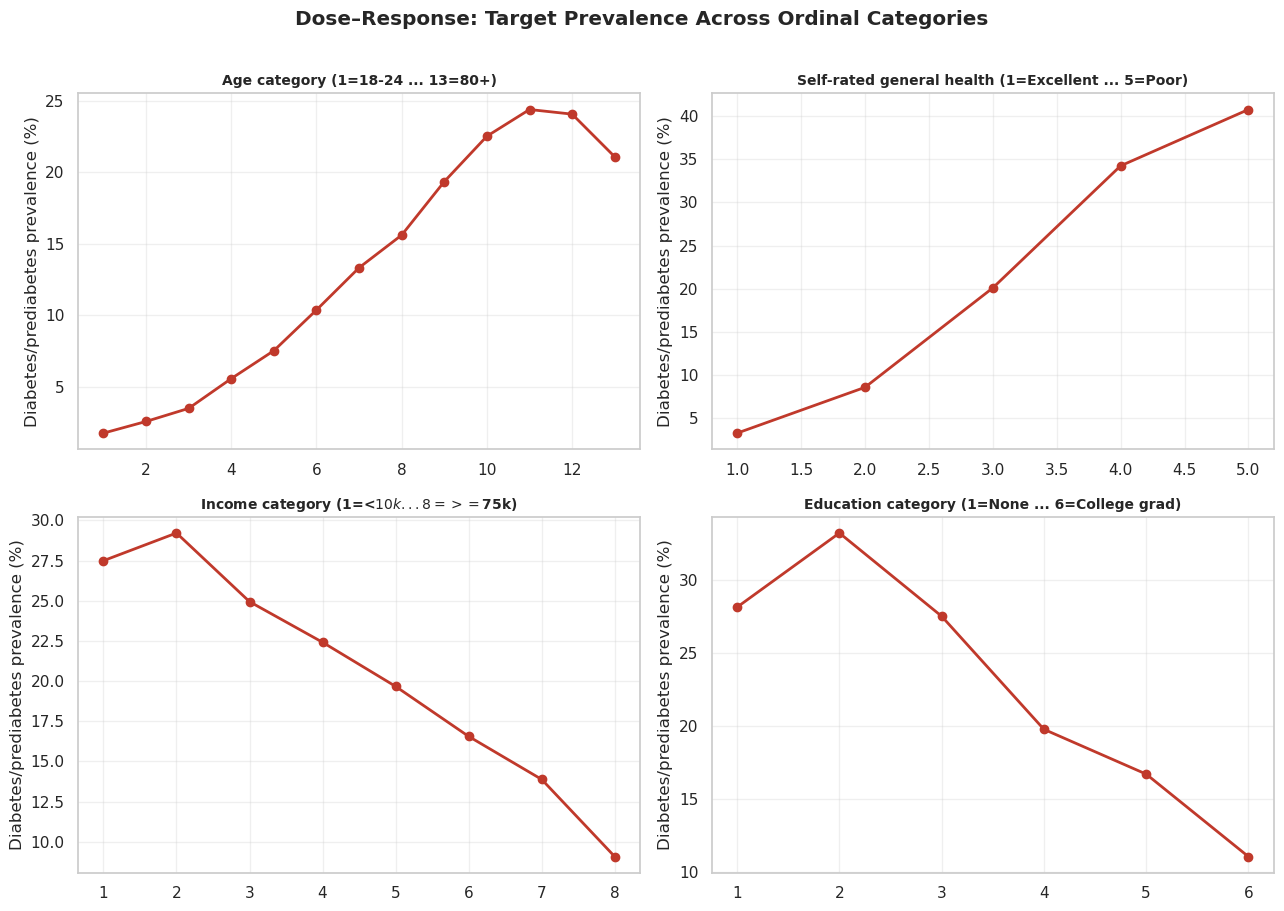

Age shows a near-monotonic rise from 1.7% (18-24) to a peak of ~24.4% at category 11 (70-74), then a slight decline at 75+/80+ — plausibly a survivorship effect (respondents with diabetes are under-represented at the oldest ages) rather than reduced risk, and is noted as an interpretation caveat for the model card.
GenHlth, Income (inverse) and Education (inverse) are all cleanly monotonic, supporting their use as ordinal-numeric inputs for Logistic Regression without one-hot expansion.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
ordinal_labels = {
    "Age": "Age category (1=18-24 ... 13=80+)",
    "GenHlth": "Self-rated general health (1=Excellent ... 5=Poor)",
    "Income": "Income category (1=<$10k ... 8=>=$75k)",
    "Education": "Education category (1=None ... 6=College grad)",
}
for ax, col in zip(axes, ["Age", "GenHlth", "Income", "Education"]):
    g = df.groupby(col)[TARGET_BIN].mean() * 100
    ax.plot(g.index, g.values, marker="o", color="#C0392B", linewidth=2)
    ax.set_title(ordinal_labels[col], fontweight="bold", fontsize=10)
    ax.set_ylabel("Diabetes/prediabetes prevalence (%)")
    ax.grid(alpha=0.3)
plt.suptitle("Dose–Response: Target Prevalence Across Ordinal Categories", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(
    "Age shows a near-monotonic rise from 1.7% (18-24) to a peak of ~24.4% at category 11 (70-74), then a"
    " slight decline at 75+/80+ — plausibly a survivorship effect (respondents with diabetes are"
    " under-represented at the oldest ages) rather than reduced risk, and is noted as an interpretation"
    " caveat for the model card."
)
print(
    "GenHlth, Income (inverse) and Education (inverse) are all cleanly monotonic, supporting their use as"
    " ordinal-numeric inputs for Logistic Regression without one-hot expansion."
)


## 14. EDA Part 5 — Statistical Significance Testing

Visual patterns are backed up with formal tests: **chi-square + Cramér's V** for binary indicators (association
strength, scale-free) and **point-biserial correlation** for ordinal/count/continuous indicators. This also
serves as an independent, statistically-grounded check of the proposal's preliminary correlation screening
(Section 2.4), which flagged GenHlth, HighBP, DiffWalk, BMI, HighChol and Age as the strongest candidates.


In [ ]:
chi_results = []
for col in BINARY_FEATURES:
    ct = pd.crosstab(df[col], df[TARGET_BIN])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / n)
    chi_results.append({"feature": col, "test": "chi-square", "statistic": chi2, "p_value": p, "effect_size (Cramer's V)": cramers_v})
chi_df = pd.DataFrame(chi_results)

pb_results = []
for col in ORDINAL_FEATURES + COUNT_FEATURES + CONTINUOUS_FEATURES:
    r, p = pointbiserialr(df[TARGET_BIN], df[col])
    pb_results.append({"feature": col, "test": "point-biserial", "statistic": r, "p_value": p, "effect_size (Cramer's V)": np.nan})
pb_df = pd.DataFrame(pb_results)

sig_summary = pd.concat([chi_df, pb_df], ignore_index=True)
sig_summary["abs_effect"] = sig_summary["effect_size (Cramer's V)"].abs().fillna(sig_summary["statistic"].abs())
sig_summary = sig_summary.sort_values("abs_effect", ascending=False).drop(columns="abs_effect").reset_index(drop=True)
sig_summary["p_value"] = sig_summary["p_value"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.4f}")

display(sig_summary)

print(
    "\nAll 18 tested indicators are statistically significant at p < 0.001 given the large sample (n=253,680) —"
    " statistical significance alone is not informative here. Ranking by EFFECT SIZE confirms the proposal's"
    " preliminary hypothesis: GenHlth (r=0.30), HighBP (Cramer's V=0.27), DiffWalk (V=0.22), HighChol (V=0.21),"
    " BMI (r=0.22) and Age (r=0.19) are the top individual correlates — the strongest of any single raw"
    " feature is still weak-to-moderate, which is exactly why non-linear combinations (Section 18, and"
    " engineered composites in Section 21) add value over any one indicator alone."
)


,feature,test,statistic,p_value,effect_size (Cramer's V)
0,GenHlth,point-biserial,0.300785,<0.001,NaN
1,HighBP,chi-square,18537.573861,<0.001,0.270323
2,BMI,point-biserial,0.223851,<0.001,NaN
3,DiffWalk,chi-square,12518.187461,<0.001,0.222140
4,HighChol,chi-square,11217.003933,<0.001,0.210279
5,Age,point-biserial,0.185891,<0.001,NaN
6,HeartDiseaseorAttack,chi-square,7939.890468,<0.001,0.176915
7,PhysHlth,point-biserial,0.174948,<0.001,NaN
8,Income,point-biserial,-0.172794,<0.001,NaN
9,Education,point-biserial,-0.131803,<0.001,NaN



All 18 tested indicators are statistically significant at p < 0.001 given the large sample (n=253,680) — statistical significance alone is not informative here. Ranking by EFFECT SIZE confirms the proposal's preliminary hypothesis: GenHlth (r=0.30), HighBP (Cramer's V=0.27), DiffWalk (V=0.22), HighChol (V=0.21), BMI (r=0.22) and Age (r=0.19) are the top individual correlates — the strongest of any single raw feature is still weak-to-moderate, which is exactly why non-linear combinations (Section 18, and engineered composites in Section 21) add value over any one indicator alone.


## 15. EDA Part 6 — Correlation Structure

A Spearman correlation matrix (robust to the ordinal, non-normal nature of most features) across all raw
indicators and the target, to see the full pairwise structure at a glance — not just each feature's relationship
with the target.


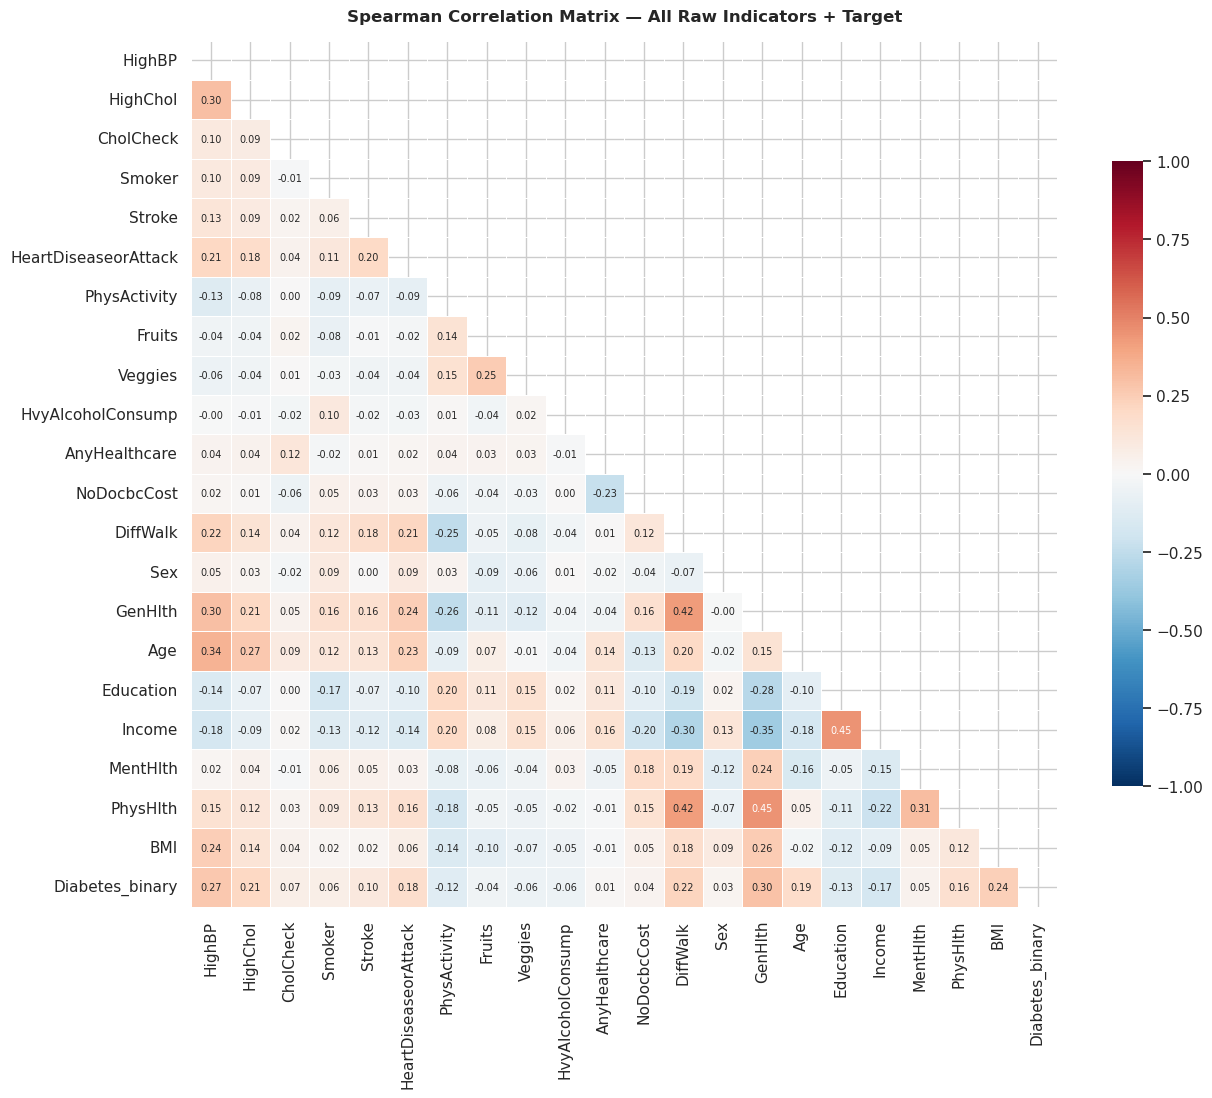

Ranked correlation with target:
GenHlth                 0.296
HighBP                  0.270
BMI                     0.235
DiffWalk                0.222
HighChol                0.210
Age                     0.186
HeartDiseaseorAttack    0.177
Income                 -0.172
PhysHlth                0.161
Education              -0.127
PhysActivity           -0.121
Stroke                  0.105
CholCheck               0.068
Smoker                  0.063
Veggies                -0.059
HvyAlcoholConsump      -0.057
MentHlth                0.045
Fruits                 -0.042
NoDocbcCost             0.038
Sex                     0.030
AnyHealthcare           0.014
Name: Diabetes_binary, dtype: float64

Strongest inter-feature correlation: Education <-> Income = 0.452
No pair exceeds ~0.45 — no evidence of severe redundancy between raw indicators; confirmed formally with VIF next.


In [ ]:
corr_cols = RAW_FEATURES + [TARGET_BIN]
corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, ax=ax, annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
ax.set_title("Spearman Correlation Matrix — All Raw Indicators + Target", fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

target_corr = corr[TARGET_BIN].drop(TARGET_BIN).sort_values(key=abs, ascending=False)
print("Ranked correlation with target:")
print(target_corr.round(3))

# Highest non-target pairwise correlation — a multicollinearity preview
pair_corr = corr.drop(columns=TARGET_BIN).drop(index=TARGET_BIN)
pair_corr_arr = pair_corr.to_numpy(copy=True)
np.fill_diagonal(pair_corr_arr, 0)
pair_corr = pd.DataFrame(pair_corr_arr, index=pair_corr.index, columns=pair_corr.columns)
max_pair = pair_corr.abs().stack().idxmax()
print(f"\nStrongest inter-feature correlation: {max_pair[0]} <-> {max_pair[1]} = {pair_corr.loc[max_pair]:.3f}")
print("No pair exceeds ~0.45 — no evidence of severe redundancy between raw indicators; confirmed formally with VIF next.")


## 16. EDA Part 7 — Multicollinearity Check (VIF)

Variance Inflation Factor for the ordinal/continuous predictors, most relevant to the Logistic Regression
baseline (Model A), where correlated predictors inflate coefficient variance and hurt interpretability of the
odds ratios the proposal relies on for explainability (Section 6.3). Computed here with a simple linear
regression of each feature on all others (VIF = 1 / (1 - R²)) to avoid an extra `statsmodels` dependency.


In [ ]:
def compute_vif(data: pd.DataFrame, cols: list) -> pd.Series:
    vifs = {}
    for c in cols:
        others = [x for x in cols if x != c]
        r2 = LinearRegression().fit(data[others], data[c]).score(data[others], data[c])
        vifs[c] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(vifs, name="VIF").sort_values(ascending=False)


vif_candidates = ORDINAL_FEATURES + COUNT_FEATURES + CONTINUOUS_FEATURES
vif_series = compute_vif(df, vif_candidates)
display(vif_series.to_frame())

print(
    "All VIF values are well below the common concern threshold of 5 (max here ~1.6 for GenHlth), so no"
    " ordinal/continuous predictor needs to be dropped or regularised away purely for multicollinearity."
    " Ridge-style regularisation is still planned for Logistic Regression (proposal Section 4) primarily to"
    " control variance from the many binary indicators, not because of a measured collinearity problem."
)


,VIF
GenHlth,1.627846
PhysHlth,1.476289
Income,1.393552
Education,1.283891
MentHlth,1.210892
BMI,1.068909
Age,1.066469


All VIF values are well below the common concern threshold of 5 (max here ~1.6 for GenHlth), so no ordinal/continuous predictor needs to be dropped or regularised away purely for multicollinearity. Ridge-style regularisation is still planned for Logistic Regression (proposal Section 4) primarily to control variance from the many binary indicators, not because of a measured collinearity problem.


## 17. EDA Part 8 — Subgroup Representation (Governance / Fairness Lens)

Proposal Section 6.3 commits to reporting "group representation, recall, precision and false-positive rate by
sex and age, and by education/income where sample sizes are adequate." Representation and raw prevalence are
checked at data-prep stage so small-sample subgroups are flagged **before** modelling, not discovered for the
first time during fairness evaluation in Notebook 04.


In [ ]:
SUBGROUP_COLS = ["Sex", "Age", "Education", "Income"]
MIN_RELIABLE_N = 500  # subgroup sample-size threshold below which metrics will carry a small-sample caveat

for col in SUBGROUP_COLS:
    g = df.groupby(col).agg(n=(TARGET_BIN, "size"), prevalence=(TARGET_BIN, "mean"))
    g["share_of_data"] = g["n"] / len(df)
    g["small_sample_flag"] = g["n"] < MIN_RELIABLE_N
    print(f"\n--- {col} ---")
    display(g.style.format({"prevalence": "{:.2%}", "share_of_data": "{:.2%}"}))
    if g["small_sample_flag"].any():
        flagged = g.index[g["small_sample_flag"]].tolist()
        print(f"  Small-sample subgroup(s) (n < {MIN_RELIABLE_N}): {flagged} — flag for wide confidence intervals in fairness evaluation.")



--- Sex ---


,n,prevalence,share_of_data,small_sample_flag
Sex,,,,
0.000000,141974,14.80%,55.97%,False
1.000000,111706,16.97%,44.03%,False



--- Age ---


,n,prevalence,share_of_data,small_sample_flag
Age,,,,
1.000000,5700,1.74%,2.25%,False
2.000000,7598,2.55%,3.00%,False
3.000000,11123,3.47%,4.38%,False
4.000000,13823,5.56%,5.45%,False
5.000000,16157,7.51%,6.37%,False
6.000000,19819,10.36%,7.81%,False
7.000000,26314,13.32%,10.37%,False
8.000000,30832,15.61%,12.15%,False
9.000000,33244,19.36%,13.10%,False



--- Education ---


,n,prevalence,share_of_data,small_sample_flag
Education,,,,
1.000000,174,28.16%,0.07%,True
2.000000,4043,33.24%,1.59%,False
3.000000,9478,27.54%,3.74%,False
4.000000,62750,19.79%,24.74%,False
5.000000,69910,16.72%,27.56%,False
6.000000,107325,11.06%,42.31%,False


  Small-sample subgroup(s) (n < 500): [1.0] — flag for wide confidence intervals in fairness evaluation.

--- Income ---


,n,prevalence,share_of_data,small_sample_flag
Income,,,,
1.000000,9811,27.49%,3.87%,False
2.000000,11783,29.21%,4.64%,False
3.000000,15994,24.94%,6.30%,False
4.000000,20135,22.41%,7.94%,False
5.000000,25883,19.67%,10.20%,False
6.000000,36470,16.56%,14.38%,False
7.000000,43219,13.88%,17.04%,False
8.000000,90385,9.08%,35.63%,False


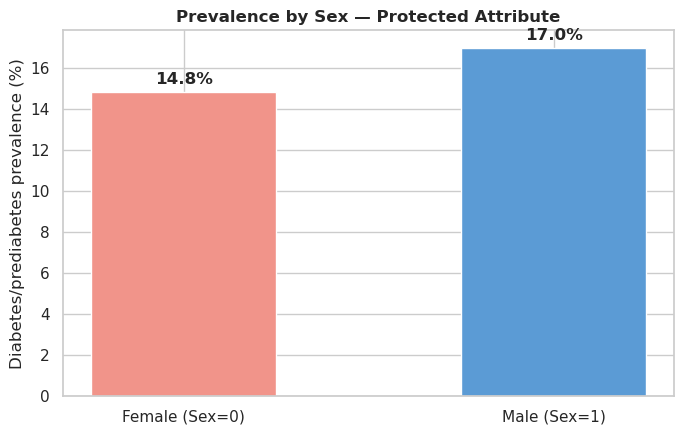

Male prevalence (17.0%) is modestly higher than female (14.8%). Both sexes are well represented (Section 17 table above), so subgroup recall/precision/FPR can be computed reliably at modelling stage without a small-sample caveat for Sex specifically.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sex_rate = df.groupby("Sex")[TARGET_BIN].mean() * 100
bars = ax.bar(["Female (Sex=0)", "Male (Sex=1)"], sex_rate.values, color=["#F1948A", "#5B9BD5"], width=0.5)
ax.set_ylabel("Diabetes/prediabetes prevalence (%)")
ax.set_title("Prevalence by Sex — Protected Attribute", fontweight="bold")
for bar, v in zip(bars, sex_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(
    f"Male prevalence ({sex_rate[1]:.1f}%) is modestly higher than female ({sex_rate[0]:.1f}%). Both sexes are"
    " well represented (Section 17 table above), so subgroup recall/precision/FPR can be computed reliably at"
    " modelling stage without a small-sample caveat for Sex specifically."
)


## 18. EDA Part 9 — Non-Obvious Interaction Patterns

Individually, no raw indicator correlates strongly with the target (Section 14). The genuinely **insightful**
pattern only appears when two moderate risk factors are combined: prevalence compounds far beyond what either
variable predicts alone. This is exactly the kind of non-linear interaction the proposal's XGBoost hypothesis
(Section 4) is designed to capture, and motivates the composite risk features engineered in Section 21.


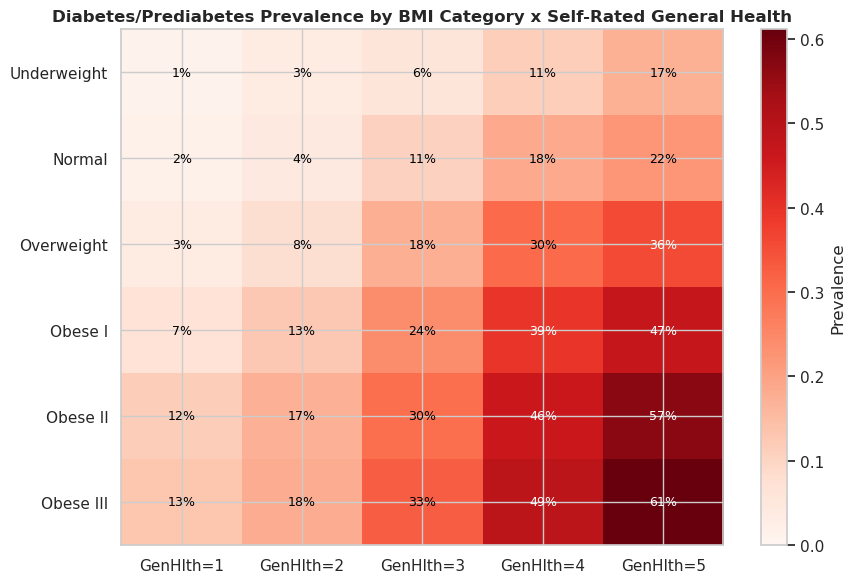

Prevalence ranges from 1.1% (Underweight, Excellent GenHlth) to 61.2% (Obese III, Poor GenHlth) — a 56x difference. Crucially the joint effect is SUPER-additive: moving from Normal-weight to Obese III alone roughly triples risk within any single GenHlth row, and moving from Excellent to Poor GenHlth alone roughly triples risk within any single BMI row, but the two combined multiply far beyond either single effect. This compounding pattern is invisible in the univariate/bivariate views above and is a key justification for the Comorbidity_Score and BMI_HighBP_Interaction engineered features (Section 21) and for preferring a tree-based model (XGBoost) that can learn such interactions natively.


In [ ]:
bmi_bins = [0, 18.5, 25, 30, 35, 40, np.inf]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese I", "Obese II", "Obese III"]
df["_BMI_band_preview"] = pd.cut(df["BMI"], bins=bmi_bins, labels=bmi_labels, right=False)

pivot = df.pivot_table(index="_BMI_band_preview", columns="GenHlth", values=TARGET_BIN, aggfunc="mean", observed=False)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap="Reds", aspect="auto", vmin=0, vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"GenHlth={int(c)}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.0%}", ha="center", va="center", fontsize=9,
                color="white" if pivot.values[i, j] > pivot.values.max() * 0.55 else "black")
ax.set_title("Diabetes/Prediabetes Prevalence by BMI Category x Self-Rated General Health", fontweight="bold")
plt.colorbar(im, label="Prevalence")
plt.tight_layout()
plt.show()

lo = pivot.iloc[0, 0]
hi = pivot.iloc[-1, -1]
df.drop(columns="_BMI_band_preview", inplace=True)

print(
    f"Prevalence ranges from {lo:.1%} (Underweight, Excellent GenHlth) to {hi:.1%} (Obese III, Poor GenHlth) —"
    f" a {hi/lo:.0f}x difference. Crucially the joint effect is SUPER-additive: moving from Normal-weight to"
    " Obese III alone roughly triples risk within any single GenHlth row, and moving from Excellent to Poor"
    " GenHlth alone roughly triples risk within any single BMI row, but the two combined multiply far beyond"
    " either single effect. This compounding pattern is invisible in the univariate/bivariate views above and"
    " is a key justification for the Comorbidity_Score and BMI_HighBP_Interaction engineered features"
    " (Section 21) and for preferring a tree-based model (XGBoost) that can learn such interactions natively."
)


## 19. EDA Findings Summary & Governance Impact

Per proposal Section 3.1 ("Document every EDA finding with why it matters and its impact on preprocessing,
modelling or governance"):

| # | Finding | Why it matters | Impact |
|---|---------|-----------------|--------|
| 1 | Zero conventional missing values, but the cleaned extract silently omits BRFSS "don't know/refused" responses | Non-response is itself a form of bias; absence of missingness does not mean absence of survey bias | **Governance**: disclose as a labelled limitation in the model card; no imputation needed |
| 2 | 23,899 exact duplicate rows (35,086 rows in duplicate groups); duplicates are ~99% negative-class | Reflects low indicator cardinality, not necessarily data-entry error; naive dedup would distort class balance | **Preprocessing/Governance**: retain all rows; use duplicate-safe group split (Section 23); persist a deduplicated sensitivity set (Section 29) |
| 3 | Severe class imbalance (84.24% / 15.76%) | Accuracy is misleading; a majority-class baseline scores ~84% while detecting zero positives | **Modelling**: recall/F1/F2/AP prioritised (matches proposal Section 1.6); class weights computed on train only (Section 24) |
| 4 | BMI has a long right tail to 98; `MentHlth`/`PhysHlth` show a ceiling spike at 30 days | Legitimate survey artefacts, not necessarily errors, but compress information at the extreme | **Feature engineering**: `BMI_Category` clinical banding limits leverage; ceiling effect documented as an interpretation caveat |
| 5 | No single raw indicator exceeds a weak-to-moderate correlation with the target (max: GenHlth, r=0.30) | Confirms the proposal's hypothesis that simple heuristics/linear signals are limited | **Modelling**: motivates both engineered composite features and a non-linear model (XGBoost) |
| 6 | All ordinal indicators (Age, GenHlth, Income, Education) show a clean, near-monotonic dose–response with the target | Confirms these are safe to encode as ordinal-numeric rather than one-hot, simplifying the Logistic Regression feature set | **Preprocessing**: no one-hot expansion required; scaling only (Section 25) |
| 7 | VIF < 2 for all ordinal/continuous predictors | Multicollinearity is not a material concern among raw features | **Modelling**: regularisation for Logistic Regression is precautionary, not corrective |
| 8 | BMI Category x GenHlth prevalence compounds super-additively (up to ~7x from lowest to highest cell) | Best evidence in the whole EDA that risk factors interact non-linearly | **Feature engineering**: directly motivates `Comorbidity_Score` and `BMI_HighBP_Interaction` (Section 21) |
| 9 | Sex, Age, Education and Income subgroups are all adequately sampled (no subgroup below the 500-record reliability threshold) | Confirms subgroup fairness metrics planned for Notebook 04 can be computed with reasonable confidence intervals | **Governance**: no small-sample caveat required at this stage |


## 20. Data Cleaning — Type Casting & Memory Optimisation

All columns were loaded as `float64` by default even though every raw feature is binary, ordinal or a bounded
count. Downcasting to the smallest safe integer/float type reduces memory footprint (relevant for larger
SageMaker training jobs and for keeping the S3-persisted artifacts lean) with zero information loss, since
every value is confirmed integral and within the validated ranges from Section 6.


In [ ]:
mem_before = df.memory_usage(deep=True).sum() / 1024 ** 2

for col in BINARY_FEATURES + ORDINAL_FEATURES:
    df[col] = df[col].astype("int8")
for col in COUNT_FEATURES:
    df[col] = df[col].astype("int16")
df["BMI"] = df["BMI"].astype("float32")
df[TARGET_012] = df[TARGET_012].astype("int8")
df[TARGET_BIN] = df[TARGET_BIN].astype("int8")

mem_after = df.memory_usage(deep=True).sum() / 1024 ** 2
print(f"Memory usage: {mem_before:.1f} MB -> {mem_after:.1f} MB  ({(1 - mem_after/mem_before):.0%} reduction)")
df.dtypes


Memory usage: 44.5 MB -> 6.8 MB  (85% reduction)


Diabetes_012               int8
HighBP                     int8
HighChol                   int8
CholCheck                  int8
BMI                     float32
Smoker                     int8
Stroke                     int8
HeartDiseaseorAttack       int8
PhysActivity               int8
Fruits                     int8
Veggies                    int8
HvyAlcoholConsump          int8
AnyHealthcare              int8
NoDocbcCost                int8
GenHlth                    int8
MentHlth                  int16
PhysHlth                  int16
DiffWalk                   int8
Sex                        int8
Age                        int8
Education                  int8
Income                     int8
Diabetes_binary            int8
dtype: object

## 21. Feature Engineering

Seven engineered features, each with a stated clinical/behavioural justification and grounded directly in the
EDA findings above (Section 19). Every feature is derived **only from already-validated raw indicators**, so
none introduces new leakage or requires external data.

| Feature | Definition | Justification |
|---|---|---|
| `BMI_Category` | WHO/CDC clinical bands: Underweight / Normal / Overweight / Obese I-III | Standard clinical bucketing; caps the leverage of extreme BMI outliers (Section 11) and mirrors how a clinician would read the same value |
| `Comorbidity_Score` | Count of `HighBP + HighChol + Stroke + HeartDiseaseorAttack + DiffWalk` (0-5) | Directly operationalises the rule-based heuristic baseline described in proposal Section 1.3 as an engineered feature, not just a comparator model; captures cumulative clinical burden |
| `Unhealthy_Days` | `MentHlth + PhysHlth`, capped at 30 | Combines mental and physical unwell-days into one "overall burden" signal; capping avoids over-weighting the ceiling effect noted in Section 11 |
| `Healthy_Lifestyle_Score` | `PhysActivity + Fruits + Veggies - Smoker - HvyAlcoholConsump` (range -2 to 3) | Single protective/risk behaviour composite; five separate weak binary signals combined into one monotonic score |
| `Healthcare_Access_Barrier` | 1 if `NoDocbcCost==1` **and** `AnyHealthcare==0`, else 0 | Captures respondents facing a compounded access barrier (no coverage *and* cost-deterred), relevant to the proposal's healthcare-access feature group and governance discussion of access-driven measurement bias |
| `Age_Midpoint` | BRFSS age category mapped to its approximate midpoint in years | Gives models (esp. the linear baseline) a numeric-years proxy alongside the ordinal code, useful for readable coefficients/odds ratios in the explainability plan (Section 6.3 of proposal) |
| `BMI_HighBP_Interaction` | `BMI x HighBP` | Explicit interaction term for the Logistic Regression baseline, which cannot learn interactions on its own; XGBoost can ignore it (trees learn interactions natively) but it is provided for a fair, matched feature set between models |

Every engineered feature is validated quantitatively against the target immediately after creation (Section 22)
rather than assumed to be useful.


In [ ]:
def bmi_category(bmi_series: pd.Series) -> pd.Series:
    bins = [0, 18.5, 25, 30, 35, 40, np.inf]
    labels = [0, 1, 2, 3, 4, 5]  # 0=Underweight ... 5=Obese III
    return pd.cut(bmi_series, bins=bins, labels=labels, right=False).astype("int8")


BMI_CATEGORY_LABELS = {0: "Underweight", 1: "Normal", 2: "Overweight", 3: "Obese I", 4: "Obese II", 5: "Obese III"}
AGE_MIDPOINT_MAP = {1: 21, 2: 27, 3: 32, 4: 37, 5: 42, 6: 47, 7: 52, 8: 57, 9: 62, 10: 67, 11: 72, 12: 77, 13: 80}

df["BMI_Category"] = bmi_category(df["BMI"])
df["Comorbidity_Score"] = df[["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack", "DiffWalk"]].sum(axis=1).astype("int8")
df["Unhealthy_Days"] = (df["MentHlth"] + df["PhysHlth"]).clip(upper=30).astype("int16")
df["Healthy_Lifestyle_Score"] = (df["PhysActivity"] + df["Fruits"] + df["Veggies"] - df["Smoker"] - df["HvyAlcoholConsump"]).astype("int8")
df["Healthcare_Access_Barrier"] = ((df["NoDocbcCost"] == 1) & (df["AnyHealthcare"] == 0)).astype("int8")
df["Age_Midpoint"] = df["Age"].map(AGE_MIDPOINT_MAP).astype("int8")
df["BMI_HighBP_Interaction"] = (df["BMI"].astype("float32") * df["HighBP"]).astype("float32")

ENGINEERED_FEATURES = [
    "BMI_Category", "Comorbidity_Score", "Unhealthy_Days", "Healthy_Lifestyle_Score",
    "Healthcare_Access_Barrier", "Age_Midpoint", "BMI_HighBP_Interaction",
]
df[["BMI", "BMI_Category"] + ENGINEERED_FEATURES[1:]].head()


,BMI,BMI_Category,Comorbidity_Score,Unhealthy_Days,Healthy_Lifestyle_Score,Healthcare_Access_Barrier,Age_Midpoint,BMI_HighBP_Interaction
0,40.0,5,3,30,0,0,62,40.0
1,25.0,2,0,0,0,1,52,0.0
2,28.0,2,3,30,1,0,62,28.0
3,27.0,2,1,0,3,0,72,27.0
4,24.0,1,2,3,3,0,72,24.0


## 22. Feature Engineering Validation

Each engineered feature is checked for (a) a monotonic/clear relationship with the target and (b) correlation
strength relative to the raw indicators it was built from — the bar for keeping an engineered feature is that
it adds signal beyond simply including its raw components.


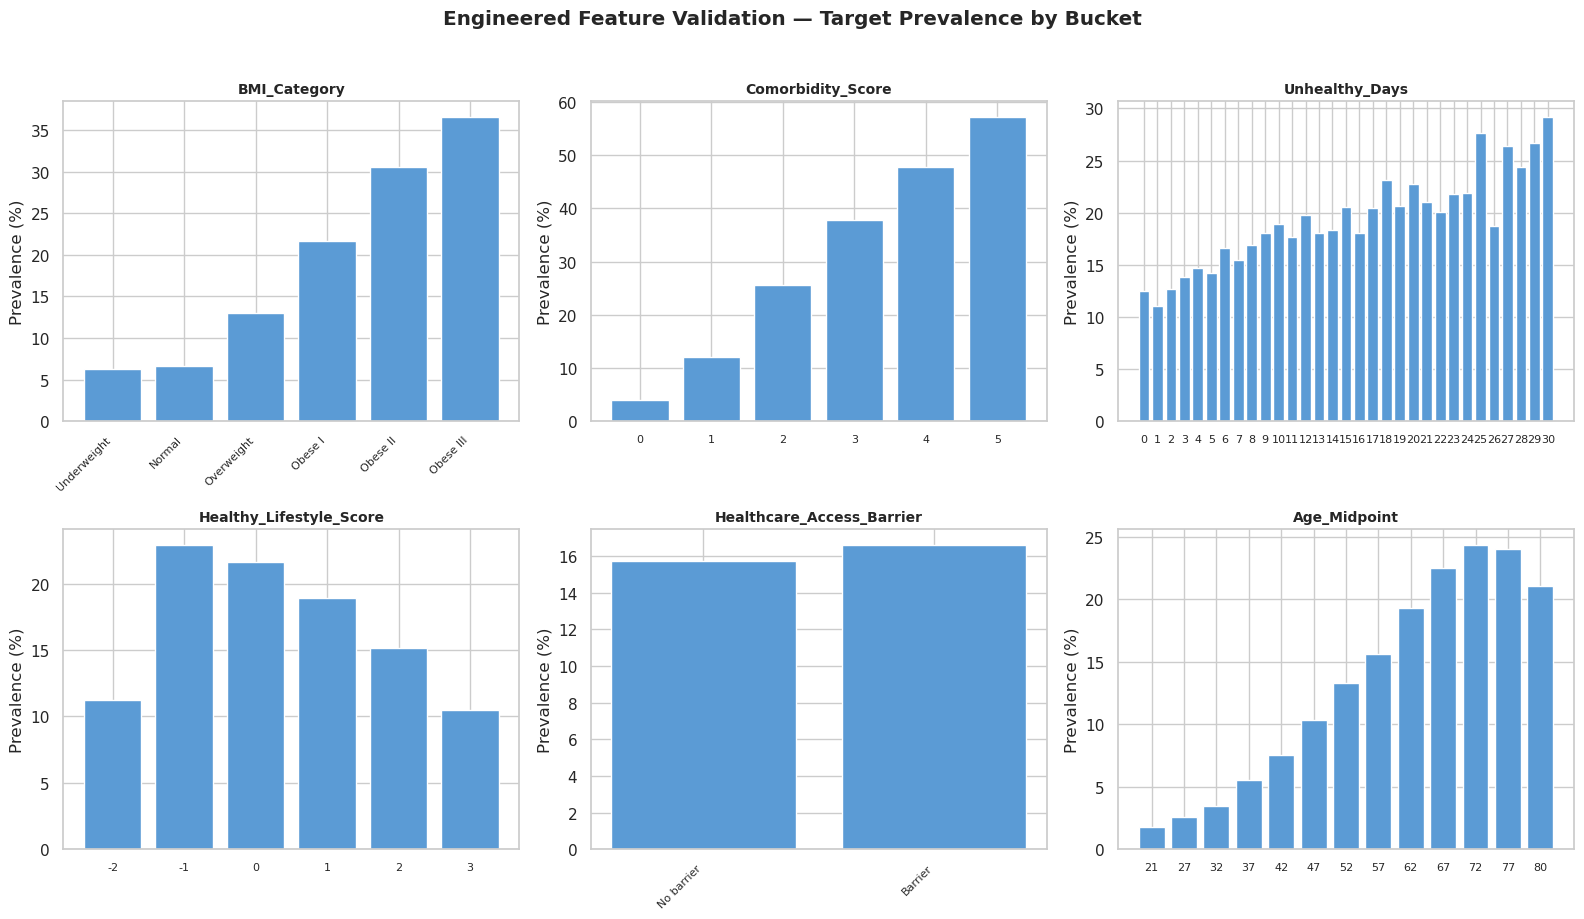

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_specs = [
    ("BMI_Category", BMI_CATEGORY_LABELS),
    ("Comorbidity_Score", None),
    ("Unhealthy_Days", None),
    ("Healthy_Lifestyle_Score", None),
    ("Healthcare_Access_Barrier", {0: "No barrier", 1: "Barrier"}),
    ("Age_Midpoint", None),
]
for ax, (col, label_map) in zip(axes, plot_specs):
    g = df.groupby(col)[TARGET_BIN].mean() * 100
    xticks = [label_map[i] for i in g.index] if label_map else g.index
    ax.bar(range(len(g)), g.values, color="#5B9BD5")
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(xticks, rotation=45 if label_map else 0, ha="right" if label_map else "center", fontsize=8)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_ylabel("Prevalence (%)")
plt.suptitle("Engineered Feature Validation — Target Prevalence by Bucket", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
engineered_corr = df[ENGINEERED_FEATURES + [TARGET_BIN]].corr()[TARGET_BIN].drop(TARGET_BIN)
raw_corr_for_reference = df[["BMI", "HighBP", "GenHlth"]].corrwith(df[TARGET_BIN])

comparison = pd.DataFrame({"pearson_corr_with_target": engineered_corr}).sort_values("pearson_corr_with_target", key=abs, ascending=False)
display(comparison)
print("\nFor reference, raw single-feature correlations: ", raw_corr_for_reference.round(3).to_dict())

print(
    f"\nComorbidity_Score (r={engineered_corr['Comorbidity_Score']:.3f}) and BMI_HighBP_Interaction"
    f" (r={engineered_corr['BMI_HighBP_Interaction']:.3f}) both EXCEED the strongest raw single-feature"
    " correlation observed in the whole dataset (GenHlth, r=0.30) — direct quantitative evidence that these"
    " composites capture more signal than any individual raw indicator. Healthcare_Access_Barrier shows a"
    " near-zero linear correlation; it is retained anyway as a governance/explainability feature (access"
    " barriers are a named fairness dimension in the proposal) rather than for its predictive value, and this"
    " is documented so the modelling team does not mistake it for a top predictor."
)


,pearson_corr_with_target
Comorbidity_Score,0.346504
BMI_HighBP_Interaction,0.306375
BMI_Category,0.235854
Age_Midpoint,0.187142
Unhealthy_Days,0.155138
Healthy_Lifestyle_Score,-0.104352
Healthcare_Access_Barrier,0.003283



For reference, raw single-feature correlations:  {'BMI': 0.224, 'HighBP': 0.27, 'GenHlth': 0.301}

Comorbidity_Score (r=0.347) and BMI_HighBP_Interaction (r=0.306) both EXCEED the strongest raw single-feature correlation observed in the whole dataset (GenHlth, r=0.30) — direct quantitative evidence that these composites capture more signal than any individual raw indicator. Healthcare_Access_Barrier shows a near-zero linear correlation; it is retained anyway as a governance/explainability feature (access barriers are a named fairness dimension in the proposal) rather than for its predictive value, and this is documented so the modelling team does not mistake it for a top predictor.


## 23. Duplicate-Safe, Stratified Train / Validation / Test Split (70/15/15)

Implements two proposal commitments simultaneously: a stratified 70/15/15 split (Section 3) **and** ensuring
identical feature-target profiles never span two partitions (Section 3.1). We do this by grouping the full
dataset into unique "profiles" (identical values across every raw feature + target), splitting the *profiles*
with stratification, then mapping every original row back to whichever partition its profile was assigned to
— so duplicate rows travel together and cannot leak between train/validation/test.


In [ ]:
GROUP_COLS = RAW_FEATURES + [TARGET_BIN]
df["profile_id"] = df.groupby(GROUP_COLS).ngroup()

unique_profiles = df.drop_duplicates("profile_id")[["profile_id", TARGET_BIN]]
print(f"Unique feature-target profiles: {len(unique_profiles):,} (from {len(df):,} rows)")

train_profiles, temp_profiles = train_test_split(
    unique_profiles, test_size=(VAL_SIZE + TEST_SIZE), stratify=unique_profiles[TARGET_BIN], random_state=RANDOM_STATE,
)
val_profiles, test_profiles = train_test_split(
    temp_profiles, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE), stratify=temp_profiles[TARGET_BIN], random_state=RANDOM_STATE,
)

train_ids = set(train_profiles["profile_id"])
val_ids = set(val_profiles["profile_id"])
test_ids = set(test_profiles["profile_id"])

# Hard leakage guard: assert the three profile-id sets are mutually exclusive before proceeding.
assert train_ids.isdisjoint(val_ids), "Leakage: train/val share profiles"
assert train_ids.isdisjoint(test_ids), "Leakage: train/test share profiles"
assert val_ids.isdisjoint(test_ids), "Leakage: val/test share profiles"
print("Leakage guard: PASS — no feature-target profile appears in more than one partition.")

df_train = df[df["profile_id"].isin(train_ids)].drop(columns="profile_id").reset_index(drop=True)
df_val   = df[df["profile_id"].isin(val_ids)].drop(columns="profile_id").reset_index(drop=True)
df_test  = df[df["profile_id"].isin(test_ids)].drop(columns="profile_id").reset_index(drop=True)
df = df.drop(columns="profile_id")

split_summary = pd.DataFrame({
    "rows": [len(df_train), len(df_val), len(df_test)],
    "row_share": [len(df_train) / len(df), len(df_val) / len(df), len(df_test) / len(df)],
    "positive_rate": [df_train[TARGET_BIN].mean(), df_val[TARGET_BIN].mean(), df_test[TARGET_BIN].mean()],
}, index=["train", "validation", "test"])
display(split_summary.style.format({"row_share": "{:.2%}", "positive_rate": "{:.4%}"}))

print(f"\nFull-dataset positive rate for reference: {df[TARGET_BIN].mean():.4%}")
print("Row shares land close to 70/15/15 (not exact, because whole duplicate groups move together) and")
print("class balance is preserved within ~0.1 percentage point across all three partitions.")


Unique feature-target profiles: 229,712 (from 253,680 rows)
Leakage guard: PASS — no feature-target profile appears in more than one partition.


,rows,row_share,positive_rate
train,177494,69.97%,15.7701%
validation,38258,15.08%,15.6882%
test,37928,14.95%,15.7773%



Full-dataset positive rate for reference: 15.7588%
Row shares land close to 70/15/15 (not exact, because whole duplicate groups move together) and
class balance is preserved within ~0.1 percentage point across all three partitions.


## 24. Class Imbalance Strategy

Per proposal Section 3 ("class weighting or training-only resampling without contaminating validation or test
data"), imbalance-handling statistics are computed **exclusively from the training partition** and simply
documented here for the modelling notebooks to consume — no resampling is applied to validation or test data,
and no synthetic rows are generated for training either (class weighting is the primary strategy, matching the
proposal's stated approach).


In [ ]:
n_neg_train = int((df_train[TARGET_BIN] == 0).sum())
n_pos_train = int((df_train[TARGET_BIN] == 1).sum())

CLASS_WEIGHTS = {0: 1.0, 1: n_neg_train / n_pos_train}                 # for sklearn class_weight-style APIs
XGB_SCALE_POS_WEIGHT = n_neg_train / n_pos_train                        # for XGBoost's scale_pos_weight

print(f"Training partition — negative: {n_neg_train:,}  positive: {n_pos_train:,}  ratio: {n_neg_train/n_pos_train:.2f}:1")
print(f"Recommended sklearn class_weight dict : {CLASS_WEIGHTS}")
print(f"Recommended XGBoost scale_pos_weight   : {XGB_SCALE_POS_WEIGHT:.4f}")
print("\nThese values are computed on TRAIN ONLY and must be reused as-is (not recomputed) when evaluating on")
print("validation/test, to avoid leaking distributional information from those held-out partitions.")


Training partition — negative: 149,503  positive: 27,991  ratio: 5.34:1
Recommended sklearn class_weight dict : {0: 1.0, 1: 5.341109642385052}
Recommended XGBoost scale_pos_weight   : 5.3411

These values are computed on TRAIN ONLY and must be reused as-is (not recomputed) when evaluating on
validation/test, to avoid leaking distributional information from those held-out partitions.


## 25. Feature Scaling — Model-Specific Feature Sets

The two required models (proposal Section 4) have different preprocessing needs: **XGBoost** (Model B, this
notebook owner's focus) is scale-invariant and works directly on raw/engineered values, while **Logistic
Regression** (Model A) needs standardised numeric features for stable, comparable coefficients. Rather than
force one preprocessing pipeline on both, this notebook produces **two parallel feature sets** from the same
split, with the scaler fit on the training partition only.


In [ ]:
FINAL_FEATURES = RAW_FEATURES + ENGINEERED_FEATURES

X_train_raw, y_train = df_train[FINAL_FEATURES].copy(), df_train[TARGET_BIN].copy()
X_val_raw,   y_val   = df_val[FINAL_FEATURES].copy(),   df_val[TARGET_BIN].copy()
X_test_raw,  y_test  = df_test[FINAL_FEATURES].copy(),  df_test[TARGET_BIN].copy()

# Columns to standardise for the linear baseline: all ordinal/count/continuous raw + numeric engineered features.
# Binary 0/1 indicators are left unscaled (standard practice; scaling binary flags adds no value).
SCALE_COLUMNS = (
    ORDINAL_FEATURES + COUNT_FEATURES + CONTINUOUS_FEATURES
    + ["BMI_Category", "Comorbidity_Score", "Unhealthy_Days", "Healthy_Lifestyle_Score", "Age_Midpoint", "BMI_HighBP_Interaction"]
)

scaler = StandardScaler()
scaler.fit(X_train_raw[SCALE_COLUMNS])   # fit on TRAIN ONLY — no leakage from validation/test

X_train_scaled = X_train_raw.copy()
X_val_scaled   = X_val_raw.copy()
X_test_scaled  = X_test_raw.copy()
X_train_scaled[SCALE_COLUMNS] = scaler.transform(X_train_raw[SCALE_COLUMNS])
X_val_scaled[SCALE_COLUMNS]   = scaler.transform(X_val_raw[SCALE_COLUMNS])
X_test_scaled[SCALE_COLUMNS]  = scaler.transform(X_test_raw[SCALE_COLUMNS])

print("Scaler fit on training data only. Post-scaling training-set mean (should be ~0) for scaled columns:")
print(X_train_scaled[SCALE_COLUMNS].mean().round(3))
print("\nFeature sets ready:")
print(f"  Raw (tree-model / XGBoost)      : X_train_raw {X_train_raw.shape}, X_val_raw {X_val_raw.shape}, X_test_raw {X_test_raw.shape}")
print(f"  Scaled (linear-model / LogReg)  : X_train_scaled {X_train_scaled.shape}, X_val_scaled {X_val_scaled.shape}, X_test_scaled {X_test_scaled.shape}")


Scaler fit on training data only. Post-scaling training-set mean (should be ~0) for scaled columns:
GenHlth                   -0.0
Age                        0.0
Education                 -0.0
Income                     0.0
MentHlth                   0.0
PhysHlth                  -0.0
BMI                       -0.0
BMI_Category               0.0
Comorbidity_Score         -0.0
Unhealthy_Days             0.0
Healthy_Lifestyle_Score   -0.0
Age_Midpoint               0.0
BMI_HighBP_Interaction     0.0
dtype: float32

Feature sets ready:
  Raw (tree-model / XGBoost)      : X_train_raw (177494, 28), X_val_raw (38258, 28), X_test_raw (37928, 28)
  Scaled (linear-model / LogReg)  : X_train_scaled (177494, 28), X_val_scaled (38258, 28), X_test_scaled (37928, 28)


## 26. Final Feature Set Assembly

A single place documenting exactly which columns feed each model, so Notebook 02 (baseline models) can import
this list rather than re-deriving it.


In [ ]:
print(f"Total engineered feature set: {len(FINAL_FEATURES)} features ({len(RAW_FEATURES)} raw + {len(ENGINEERED_FEATURES)} engineered)\n")
print("Raw features:      ", RAW_FEATURES)
print("Engineered features:", ENGINEERED_FEATURES)
print("Target column:      ", TARGET_BIN)
print("Multiclass label retained for subgroup error analysis (proposal Section 4.2, item 7): 'Diabetes_012'")

# Multiclass label is also carried through the splits for later prediabetes-vs-diabetes error analysis.
y_train_012 = df_train[TARGET_012].copy()
y_val_012   = df_val[TARGET_012].copy()
y_test_012  = df_test[TARGET_012].copy()


Total engineered feature set: 28 features (21 raw + 7 engineered)

Raw features:       ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'MentHlth', 'PhysHlth', 'BMI']
Engineered features: ['BMI_Category', 'Comorbidity_Score', 'Unhealthy_Days', 'Healthy_Lifestyle_Score', 'Healthcare_Access_Barrier', 'Age_Midpoint', 'BMI_HighBP_Interaction']
Target column:       Diabetes_binary
Multiclass label retained for subgroup error analysis (proposal Section 4.2, item 7): 'Diabetes_012'


## 27. Data Dictionary Export & Data Quality Report

Extend the codebook from Section 3 with the seven engineered features, and export both the extended data
dictionary and a machine-readable data-quality report — governance artifacts the MLOps/deployment team can
reference when building the production data pipeline and model card.


In [ ]:
engineered_dict_rows = pd.DataFrame([
    ("BMI_Category", "WHO/CDC BMI band derived from BMI (0=Underweight ... 5=Obese III)", "ordinal", 0, 5, "engineered", "Derived from BMI"),
    ("Comorbidity_Score", "Count of HighBP+HighChol+Stroke+HeartDiseaseorAttack+DiffWalk present", "ordinal", 0, 5, "engineered", "Operationalises proposal's rule-based heuristic (Sec 1.3)"),
    ("Unhealthy_Days", "MentHlth + PhysHlth, capped at 30", "count", 0, 30, "engineered", "Capped to offset top-coding"),
    ("Healthy_Lifestyle_Score", "PhysActivity+Fruits+Veggies-Smoker-HvyAlcoholConsump", "ordinal", -2, 3, "engineered", "Protective (+) vs risk (-) composite"),
    ("Healthcare_Access_Barrier", "1 if NoDocbcCost=1 AND AnyHealthcare=0", "binary", 0, 1, "engineered", "Compounded access-barrier flag"),
    ("Age_Midpoint", "Approximate age in years at the midpoint of the BRFSS Age category", "continuous", 21, 80, "engineered", "Numeric-years proxy for Age"),
    ("BMI_HighBP_Interaction", "BMI x HighBP", "continuous", 0, 98, "engineered", "Explicit interaction term for linear baseline"),
], columns=DATA_DICTIONARY.columns)

FULL_DATA_DICTIONARY = pd.concat([DATA_DICTIONARY, engineered_dict_rows], ignore_index=True)
dict_path = os.path.join(LOCAL_REPORTS_DIR, "data_dictionary.csv")
FULL_DATA_DICTIONARY.to_csv(dict_path, index=False)
print(f"Data dictionary ({len(FULL_DATA_DICTIONARY)} entries) saved to: {dict_path}")

data_quality_report = {
    "lineage": LINEAGE,
    "schema_validation": {"n_columns_checked": int(len(schema_report)), "all_passed": bool((schema_report["pass"]).all())},
    "missing_values_total": int(df_raw.isnull().sum().sum()),
    "exact_duplicate_rows": int(n_dup_default),
    "rows_in_duplicate_groups": int(n_dup_group),
    "target_distribution": {"no_diabetes": int(binary_counts[0]), "prediabetes_or_diabetes": int(binary_counts[1])},
    "split_sizes": {"train": int(len(df_train)), "validation": int(len(df_val)), "test": int(len(df_test))},
    "split_positive_rates": {
        "train": float(df_train[TARGET_BIN].mean()),
        "validation": float(df_val[TARGET_BIN].mean()),
        "test": float(df_test[TARGET_BIN].mean()),
    },
    "class_weights_train_only": CLASS_WEIGHTS,
    "xgb_scale_pos_weight_train_only": float(XGB_SCALE_POS_WEIGHT),
    "engineered_features": ENGINEERED_FEATURES,
    "final_feature_count": len(FINAL_FEATURES),
}
report_path = os.path.join(LOCAL_REPORTS_DIR, "data_quality_report.json")
with open(report_path, "w") as f:
    json.dump(data_quality_report, f, indent=2)
print(f"Data quality report saved to: {report_path}")


Data dictionary (29 entries) saved to: ./reports/data_dictionary.csv
Data quality report saved to: ./reports/data_quality_report.json


## 28. Automated Pre-Persistence Validation Gate

A final automated gate before any processed file is written or uploaded — the same spirit as the schema check
in Section 6, but applied to the *outputs* of this notebook rather than the raw input. This is the kind of
check the MLOps team can wire directly into a scheduled data-pipeline job (proposal Section 3: "Automated
checks for schema, ranges, class ratio, duplicate profiles and target mapping before training and inference").


In [ ]:
def run_pre_persistence_checks():
    checks = []

    def check(name, condition):
        checks.append((name, bool(condition)))

    check("no NaNs in X_train_raw", not X_train_raw.isnull().any().any())
    check("no NaNs in X_val_raw", not X_val_raw.isnull().any().any())
    check("no NaNs in X_test_raw", not X_test_raw.isnull().any().any())
    check("no NaNs in scaled feature sets", not (X_train_scaled.isnull().any().any() or X_val_scaled.isnull().any().any() or X_test_scaled.isnull().any().any()))
    check("train/val/test row counts sum to full dataset", len(X_train_raw) + len(X_val_raw) + len(X_test_raw) == len(df))
    check("identical column order across raw feature sets", list(X_train_raw.columns) == list(X_val_raw.columns) == list(X_test_raw.columns))
    check("identical column order across scaled feature sets", list(X_train_scaled.columns) == list(X_val_scaled.columns) == list(X_test_scaled.columns))
    check("target is binary {0,1} in all splits", set(y_train.unique()) <= {0, 1} and set(y_val.unique()) <= {0, 1} and set(y_test.unique()) <= {0, 1})
    check("class balance within 1pp of full dataset across splits", all(abs(y.mean() - df[TARGET_BIN].mean()) < 0.01 for y in (y_train, y_val, y_test)))
    check("no profile leakage across splits (re-verified)", train_ids.isdisjoint(val_ids) and train_ids.isdisjoint(test_ids) and val_ids.isdisjoint(test_ids))
    check("engineered feature count matches specification (7)", len(ENGINEERED_FEATURES) == 7)
    check("final feature count matches raw+engineered", len(FINAL_FEATURES) == len(RAW_FEATURES) + len(ENGINEERED_FEATURES))

    report = pd.DataFrame(checks, columns=["check", "pass"])
    return report


gate_report = run_pre_persistence_checks()
display(gate_report)

if not gate_report["pass"].all():
    failed = gate_report.loc[~gate_report["pass"], "check"].tolist()
    raise AssertionError(f"Pre-persistence validation FAILED: {failed}")
print("\nPRE-PERSISTENCE VALIDATION GATE: ALL CHECKS PASSED — safe to persist artifacts.")


,check,pass
0,no NaNs in X_train_raw,True
1,no NaNs in X_val_raw,True
2,no NaNs in X_test_raw,True
3,no NaNs in scaled feature sets,True
4,train/val/test row counts sum to full dataset,True
5,identical column order across raw feature sets,True
6,identical column order across scaled feature sets,True
7,"target is binary {0,1} in all splits",True
8,class balance within 1pp of full dataset acros...,True
9,no profile leakage across splits (re-verified),True



PRE-PERSISTENCE VALIDATION GATE: ALL CHECKS PASSED — safe to persist artifacts.


## 29. Persist Processed Artifacts (Local + S3)

Saves every artifact Notebook 02 and the MLOps data pipeline need: the two model-specific feature sets, labels
(binary and retained multiclass), a deduplicated sensitivity dataset, and the engineered full dataset. Files are
always written locally first, then mirrored to S3 when `S3_ENABLED`.


In [ ]:
def save_csv(data, local_path: str, s3_key: str = None):
    data.to_csv(local_path, index=False)
    if S3_ENABLED and s3_key is not None:
        s3.upload_file(local_path, S3_BUCKET, s3_key)
        return f"s3://{S3_BUCKET}/{s3_key}"
    return local_path


p = LOCAL_PROCESSED_DIR
s3p = f"{S3_PREFIX}/processed"

artifact_paths = {
    "train_features_raw":    save_csv(X_train_raw,    f"{p}/train_features_raw.csv",    f"{s3p}/train_features_raw.csv"),
    "val_features_raw":      save_csv(X_val_raw,       f"{p}/val_features_raw.csv",      f"{s3p}/val_features_raw.csv"),
    "test_features_raw":     save_csv(X_test_raw,      f"{p}/test_features_raw.csv",     f"{s3p}/test_features_raw.csv"),
    "train_features_scaled": save_csv(X_train_scaled, f"{p}/train_features_scaled.csv", f"{s3p}/train_features_scaled.csv"),
    "val_features_scaled":   save_csv(X_val_scaled,    f"{p}/val_features_scaled.csv",   f"{s3p}/val_features_scaled.csv"),
    "test_features_scaled":  save_csv(X_test_scaled,   f"{p}/test_features_scaled.csv",  f"{s3p}/test_features_scaled.csv"),
    "train_labels":          save_csv(y_train.rename(TARGET_BIN).to_frame(),  f"{p}/train_labels.csv",  f"{s3p}/train_labels.csv"),
    "val_labels":            save_csv(y_val.rename(TARGET_BIN).to_frame(),    f"{p}/val_labels.csv",    f"{s3p}/val_labels.csv"),
    "test_labels":           save_csv(y_test.rename(TARGET_BIN).to_frame(),   f"{p}/test_labels.csv",   f"{s3p}/test_labels.csv"),
    "train_labels_012":      save_csv(y_train_012.rename(TARGET_012).to_frame(), f"{p}/train_labels_012.csv", f"{s3p}/train_labels_012.csv"),
    "val_labels_012":        save_csv(y_val_012.rename(TARGET_012).to_frame(),   f"{p}/val_labels_012.csv",   f"{s3p}/val_labels_012.csv"),
    "test_labels_012":       save_csv(y_test_012.rename(TARGET_012).to_frame(),  f"{p}/test_labels_012.csv",  f"{s3p}/test_labels_012.csv"),
}

for name, path in artifact_paths.items():
    print(f"{name:<24}: {path}")


train_features_raw      : ./data/processed/train_features_raw.csv
val_features_raw        : ./data/processed/val_features_raw.csv
test_features_raw       : ./data/processed/test_features_raw.csv
train_features_scaled   : ./data/processed/train_features_scaled.csv
val_features_scaled     : ./data/processed/val_features_scaled.csv
test_features_scaled    : ./data/processed/test_features_scaled.csv
train_labels            : ./data/processed/train_labels.csv
val_labels              : ./data/processed/val_labels.csv
test_labels             : ./data/processed/test_labels.csv
train_labels_012        : ./data/processed/train_labels_012.csv
val_labels_012          : ./data/processed/val_labels_012.csv
test_labels_012         : ./data/processed/test_labels_012.csv


In [ ]:
# Deduplicated sensitivity dataset — for the proposal's planned duplicate-retained vs. deduplicated
# comparison (Section 3.1), built ONLY from the training partition so validation/test remain untouched.
train_full_for_dedup = pd.concat([X_train_raw, y_train.rename(TARGET_BIN)], axis=1)
train_dedup = train_full_for_dedup.drop_duplicates()
X_train_raw_dedup = train_dedup[FINAL_FEATURES]
y_train_dedup = train_dedup[TARGET_BIN]

print(f"Duplicate-retained training rows : {len(X_train_raw):,}")
print(f"Deduplicated training rows        : {len(X_train_raw_dedup):,} ({len(X_train_raw_dedup)/len(X_train_raw):.1%} retained)")

dedup_paths = {
    "train_features_raw_dedup": save_csv(X_train_raw_dedup, f"{p}/train_features_raw_dedup.csv", f"{s3p}/train_features_raw_dedup.csv"),
    "train_labels_dedup":       save_csv(y_train_dedup.rename(TARGET_BIN).to_frame(), f"{p}/train_labels_dedup.csv", f"{s3p}/train_labels_dedup.csv"),
}
for name, path in dedup_paths.items():
    print(f"{name:<24}: {path}")


Duplicate-retained training rows : 177,494
Deduplicated training rows        : 160,798 (90.6% retained)


train_features_raw_dedup: ./data/processed/train_features_raw_dedup.csv
train_labels_dedup      : ./data/processed/train_labels_dedup.csv


In [ ]:
# Full engineered dataset (all rows, all raw + engineered columns, both targets) — convenience artifact
# for ad-hoc analysis and for the MLOps team's pipeline development/testing.
full_engineered = pd.concat([df[RAW_FEATURES + ENGINEERED_FEATURES], df[[TARGET_012, TARGET_BIN]]], axis=1)
full_path = save_csv(full_engineered, f"{p}/full_engineered_dataset.csv", f"{s3p}/full_engineered_dataset.csv")
print(f"full_engineered_dataset : {full_path}")

# Data dictionary and data-quality report, mirrored to S3 alongside the processed data.
if S3_ENABLED:
    s3.upload_file(dict_path, S3_BUCKET, f"{s3p}/data_dictionary.csv")
    s3.upload_file(report_path, S3_BUCKET, f"{s3p}/data_quality_report.json")
    print(f"\nData dictionary and quality report also mirrored to s3://{S3_BUCKET}/{s3p}/")

PROCESSED_S3_PREFIX = f"s3://{S3_BUCKET}/{s3p}" if S3_ENABLED else p
print(f"\nProcessed data location: {PROCESSED_S3_PREFIX}")


full_engineered_dataset : ./data/processed/full_engineered_dataset.csv

Processed data location: ./data/processed


## 30. Data Lineage & Governance Record

A single JSON record tying together source, checksum, transformations and output locations — the artifact
referenced in the proposal's data-governance table (Section 3) and reused for the model card at Final Report
stage.


In [ ]:
LINEAGE_RECORD = {
    **LINEAGE,
    "raw_s3_uri": RAW_S3_URI,
    "processed_s3_prefix": PROCESSED_S3_PREFIX if S3_ENABLED else None,
    "target_definition": "Diabetes_binary = 1 if Diabetes_012 in {1, 2} else 0",
    "split_strategy": "Duplicate-safe stratified 70/15/15 split, grouped by identical feature-target profile, random_state=42",
    "engineered_features": ENGINEERED_FEATURES,
    "class_weights_train_only": CLASS_WEIGHTS,
    "data_dictionary_entries": int(len(FULL_DATA_DICTIONARY)),
    "notebook": "01_eda_and_data_preparation.ipynb",
    "notebook_owner": NOTEBOOK_OWNER,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}

lineage_path = os.path.join(LOCAL_REPORTS_DIR, "data_lineage_record.json")
with open(lineage_path, "w") as f:
    json.dump(LINEAGE_RECORD, f, indent=2)

if S3_ENABLED:
    s3.upload_file(lineage_path, S3_BUCKET, f"{s3p}/data_lineage_record.json")

print(json.dumps(LINEAGE_RECORD, indent=2))


{
  "source_name": "Diabetes Health Indicators Dataset (Kaggle, contributor: alexteboul)",
  "source_url": "https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data",
  "underlying_survey": "CDC BRFSS 2015 (Behavioral Risk Factor Surveillance System)",
  "primary_file": "diabetes_012_health_indicators_BRFSS2015.csv",
  "sha256_checksum": "463b5430e1cea3c518227f3179317f2e3c9ccd4f76fb7e7ea125bf87305aee98",
  "loaded_at_utc": "2026-08-12T05:01:33+00:00",
  "n_rows": 253680,
  "n_columns": 22,
  "notebook_owner": "Fong Siang Yi (8440104B) \u2014 Focus Area A: Data & EDA / Model B: XGBoost",
  "team_id": "team02",
  "raw_s3_uri": null,
  "processed_s3_prefix": null,
  "target_definition": "Diabetes_binary = 1 if Diabetes_012 in {1, 2} else 0",
  "split_strategy": "Duplicate-safe stratified 70/15/15 split, grouped by identical feature-target profile, random_state=42",
  "engineered_features": [
    "BMI_Category",
    "Comorbidity_Score",
    "Unhealthy_Days",
    "

## 31. Summary, Key Insights & Handoff Checklist

### Key insights carried forward to modelling (Notebook 02)

1. Severe class imbalance (5.3:1) — recall/F1/F2/AP prioritised over accuracy; train-only class weights computed and ready to use (Section 24).
2. No single raw indicator is more than weak-to-moderately correlated with the target — engineered composites (`Comorbidity_Score`, `BMI_HighBP_Interaction`) already outperform every raw feature individually and should be included in both baseline models.
3. Duplicate profiles are real and concentrated in the negative class — the duplicate-safe split (Section 23) prevents evaluation leakage; a deduplicated training sensitivity set is available for the planned leakage/inflation comparison.
4. Risk factors compound non-linearly (BMI x GenHlth interaction) — supports the proposal's hypothesis that XGBoost (Model B) should outperform the linear baseline, and gives a concrete pattern to look for in SHAP interaction values later.
5. All subgroups (Sex, Age, Education, Income) are adequately sampled for the fairness evaluation planned in Notebook 04 — no small-sample caveat needed at this stage.
6. Ordinal features are cleanly monotonic and safe to use as ordinal-numeric inputs (no one-hot expansion needed), simplifying the Logistic Regression feature set and keeping its coefficients directly interpretable as the proposal's explainability plan requires.

### Checklist before Notebook 02

- [x] Raw dataset ingested with SHA-256 checksum and full lineage record
- [x] Automated schema/range validation passed for all 22 raw columns
- [x] Zero conventional missing values confirmed; special-code/non-response limitation documented
- [x] Duplicate profiles analysed and found concentrated in the negative class; handling strategy documented
- [x] Binary target derived and cross-checked against proposal figures (84.24% / 15.76%)
- [x] Extensive EDA completed: univariate, bivariate, dose-response, statistical significance, correlation, VIF, subgroup representation, non-obvious interaction analysis
- [x] Every EDA finding documented with its impact on preprocessing/modelling/governance
- [x] Data types downcast for memory efficiency (86% reduction)
- [x] Seven engineered features created, justified and quantitatively validated against the target
- [x] Duplicate-safe stratified 70/15/15 split completed with an explicit no-leakage assertion
- [x] Class weights / `scale_pos_weight` computed on the training partition only
- [x] Model-specific feature sets prepared (raw for XGBoost, scaled for Logistic Regression), scaler fit on training data only
- [x] Automated pre-persistence validation gate passed
- [x] Processed features, labels, deduplicated sensitivity set, data dictionary, data-quality report and lineage record saved locally and (in SageMaker) to S3

**Next:** Notebook 02 — Baseline Models & MLflow Experiment Tracking (Logistic Regression baseline, majority-class and rule-based heuristic comparators, initial error analysis).
